# Projet Covid19 : Exploration des données

## 1. Présentation du dataset

Ce projet utilise le dataset COVID-19 Radiography Dataset : https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database  
Il contient des radiographies pulmonaires réparties en quatre classes :

- COVID
- Normal
- Lung Opacity
- Viral Pneumonia

Chaque classe contient un dossier `images` avec les radiographies et un dossier `masks` avec les masques pulmonaires associés.

## 2. Environnement

In [1]:
#Vérification de l'environnement de travail

import sys
print(sys.executable)

C:\Users\n_a_e\anaconda3\envs\covid19_env\python.exe


In [18]:
# Chargement des bibliothèques

from pathlib import Path
import random

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import normaltest

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from scipy.stats import kruskal
import scikit_posthocs as sp

## 3. Chemins d'accès

In [3]:
data_path = Path("../../../COVID-19_Radiography_Dataset")
classes = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]

print("Chemin absolu :", data_path.resolve())
print("Dossier trouvé :", data_path.exists())

Chemin absolu : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset
Dossier trouvé : True


## 3. Structure du Dataset

In [4]:
# Nombre d'images et de masks par classe

summary = []

for class_name in classes:
    images_dir = data_path / class_name / "images"
    masks_dir = data_path / class_name / "masks"
    
    image_files = list(images_dir.glob("*.png"))
    mask_files = list(masks_dir.glob("*.png"))
    
    summary.append({
        "classe": class_name,
        "nombre_images": len(image_files),
        "nombre_masks": len(mask_files),
        "même_nombre_images_masks": len(image_files) == len(mask_files)
    })

df_summary = pd.DataFrame(summary)
df_summary

,classe,nombre_images,nombre_masks,même_nombre_images_masks
0,COVID,3373,3373,True
1,Normal,10136,10136,True
2,Lung_Opacity,5988,5988,True
3,Viral Pneumonia,1338,1338,True


Le dataset est cohérent avec l'attendu assi bien pour les dossiers images que pour les dossiers masks.

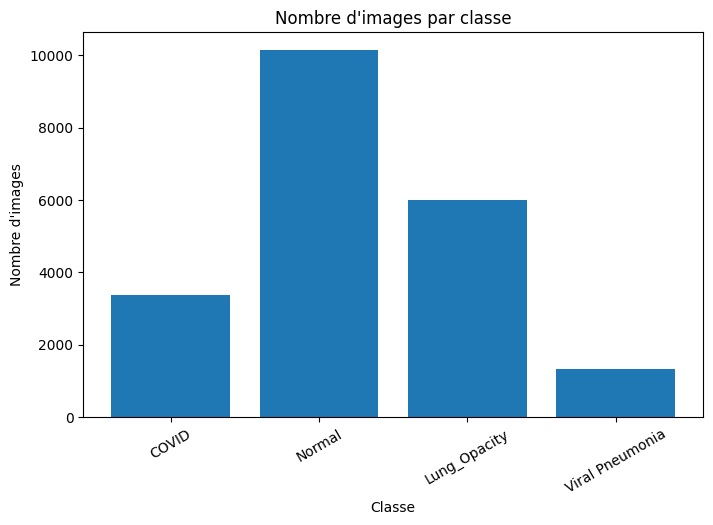

In [5]:
# Graphique de répartition des classes

plt.figure(figsize=(8, 5))
plt.bar(df_summary["classe"], df_summary["nombre_images"])
plt.title("Nombre d'images par classe")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=30)
plt.show()

Les données sont déséquilibrées avec la classe normale en majoritaire.

In [6]:
# Vérification cohérence images et masks

check_results = []

for class_name in classes:
    images_dir = data_path / class_name / "images"
    masks_dir = data_path / class_name / "masks"
    
    image_names = {f.name for f in images_dir.glob("*.png")}
    mask_names = {f.name for f in masks_dir.glob("*.png")}
    
    missing_masks = image_names - mask_names
    missing_images = mask_names - image_names
    
    check_results.append({
        "classe": class_name,
        "images_sans_mask": len(missing_masks),
        "masks_sans_image": len(missing_images)
    })

df_check = pd.DataFrame(check_results)
df_check

,classe,images_sans_mask,masks_sans_image
0,COVID,0,0
1,Normal,0,0
2,Lung_Opacity,0,0
3,Viral Pneumonia,0,0


En se basant sur la dénomination des fichiers les images et les masques sont cohérents.

## 4. Caractéristiques des images brutes

### 4.1 Qualité des données

In [7]:
# Tableau image par image

image_infos = []

for class_name in classes:
    images_dir = data_path / class_name / "images"
    
    for img_path in images_dir.glob("*.png"):
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            image_infos.append({
                "classe": class_name,
                "fichier": img_path.name,
                "erreur_lecture": True
            })
            continue
        
        height, width = img.shape
        
        image_infos.append({
            "classe": class_name,
            "fichier": img_path.name,
            "largeur": width,
            "hauteur": height,
            "nb_pixels": width * height,
            "pixel_min": img.min(),
            "pixel_max": img.max(),
            "pixel_mean": img.mean(),
            "pixel_std": img.std(),
            "dtype": img.dtype,
            "erreur_lecture": False
        })

df_images = pd.DataFrame(image_infos)
df_images.head()

,classe,fichier,largeur,hauteur,nb_pixels,pixel_min,pixel_max,pixel_mean,pixel_std,dtype,erreur_lecture
0,COVID,COVID-1.png,299,299,89401,0,255,145.896847,51.816632,uint8,False
1,COVID,COVID-10.png,299,299,89401,0,227,141.355466,40.623291,uint8,False
2,COVID,COVID-1000.png,299,299,89401,0,252,162.771054,76.249129,uint8,False
3,COVID,COVID-1001.png,299,299,89401,0,242,129.890784,66.179559,uint8,False
4,COVID,COVID-1002.png,299,299,89401,5,255,175.738761,56.926155,uint8,False


L'extraction des métadonnées s'est déroulée correctement. Toutes les images présentent une résolution de 299 × 299 pixels et aucune erreur de lecture n'a été détectée.

In [8]:
df_images.shape

(20835, 11)

Dimensions cohérentes avec l'attendu

In [9]:
df_images.describe()

,largeur,hauteur,nb_pixels,pixel_min,pixel_max,pixel_mean,pixel_std
count,20835.0,20835.0,20835.0,20835.000000,20835.000000,20835.000000,20835.000000
mean,299.0,299.0,89401.0,0.811327,243.867531,129.782081,59.021167
std,0.0,0.0,0.0,5.180663,15.935622,23.491752,11.040129
min,299.0,299.0,89401.0,0.000000,146.000000,32.226899,14.145251
25%,299.0,299.0,89401.0,0.000000,241.000000,113.205870,51.702244
50%,299.0,299.0,89401.0,0.000000,250.000000,126.872127,60.126399
75%,299.0,299.0,89401.0,0.000000,255.000000,146.513048,67.120343
max,299.0,299.0,89401.0,113.000000,255.000000,229.141676,106.998675


In [10]:
df_images.groupby("classe")[[
    "largeur", 
    "hauteur", 
    "nb_pixels", 
    "pixel_min", 
    "pixel_max", 
    "pixel_mean", 
    "pixel_std"
]].agg(["min", "max", "mean"])

largeur             hauteur             nb_pixels         \
                    min  max   mean     min  max   mean       min    max   
classe                                                                     
COVID               299  299  299.0     299  299  299.0     89401  89401   
Lung_Opacity        299  299  299.0     299  299  299.0     89401  89401   
Normal              299  299  299.0     299  299  299.0     89401  89401   
Viral Pneumonia     299  299  299.0     299  299  299.0     89401  89401   

                         pixel_min  ...           pixel_max                   \
                    mean       min  ...      mean       min  max        mean   
classe                              ...                                        
COVID            89401.0         0  ...  3.436110       147  255  240.302105   
Lung_Opacity     89401.0         0  ...  0.262024       156  255  241.661657   
Normal           89401.0         0  ...  0.260162       146  255  247.098757   
Viral Pneumonia  89401.0         0  ...  0.828102       152  255  238.249626   

                pixel_mean                          pixel_std              \
                       min         max        mean        min         max   
classe                                                                      
COVID            42.052706  216.342412  139.513797  14.145251  106.998675   
Lung_Opacity     32.226899  229.141676  126.003208  26.788407   93.454276   
Normal           39.755775  201.849543  129.358246  19.176520   98.862049   
Viral Pneumonia  64.772698  193.691961  125.371626  24.163092   87.315388   

                            
                      mean  
classe                      
COVID            54.687973  
Lung_Opacity     57.337629  
Normal           61.491792  
Viral Pneumonia  58.763049  

[4 rows x 21 columns]

In [12]:
# Les images ont-elles toutes la même taille ?

df_images[["largeur","hauteur"]].drop_duplicates()

,largeur,hauteur
0,299,299


In [13]:
# Y-a-t-il des images corrompues ?

df_images["erreur_lecture"].value_counts()

erreur_lecture
False    21165
Name: count, dtype: int64

In [14]:
# Les images sont-elles homogènes ?

df_images.groupby("classe")["pixel_mean"].describe()

,count,mean,std,min,25%,50%,75%,max
classe,,,,,,,,
COVID,3616.0,139.521210,25.029784,25.511381,126.883094,142.594753,155.970733,216.561839
Lung_Opacity,6012.0,126.021596,23.570601,32.226899,110.578643,120.819543,142.098830,229.141676
Normal,10192.0,129.389800,22.448670,26.443597,113.520593,125.509709,143.643505,201.849543
Viral Pneumonia,1345.0,125.369630,18.980974,64.772698,113.497880,126.860013,137.787776,193.691961


Les contrôles de qualité montrent que l'ensemble des images possède une résolution homogène de 299 × 299 pixels et qu'aucune erreur de lecture n'a été détectée. L'analyse des intensités moyennes par classe révèle une variabilité modérée entre les catégories, les images COVID présentant une luminosité moyenne légèrement plus élevée que les autres classes. Cette hétérogénéité reflète les différences de contraste entre les radiographies et justifie la poursuite des analyses exploratoires.

### 4.2 Statistiques exploratoires

#### Intensité moyenne des pixels

##### Distribution et normalité

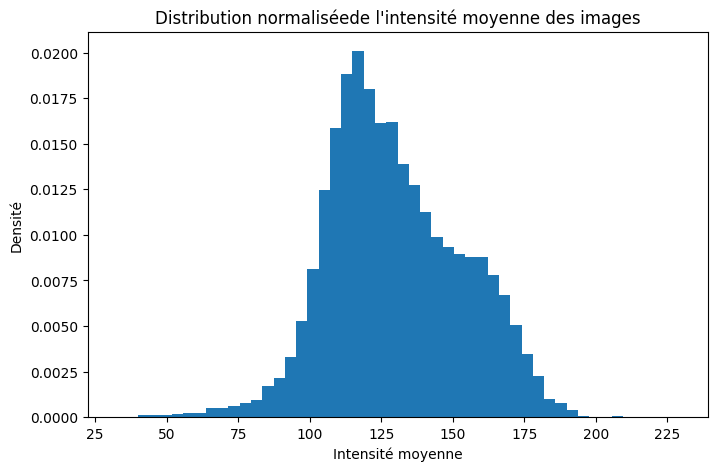

In [11]:
# Distribution des intensités moyennes des pixels

plt.figure(figsize=(8, 5))
plt.hist(df_images["pixel_mean"], bins=50, density=True,)
plt.title("Distribution normaliséede l'intensité moyenne des images")
plt.xlabel("Intensité moyenne")
plt.ylabel("Densité")
plt.show()

Au regard de l'asymétrie de la distribution, il convient de tester la normalité des données. Je chois de réaliser une approche graphique par analyse du QQ-plot, et un test d'Agostino-Pearson, adapté aux grands jeux de données.

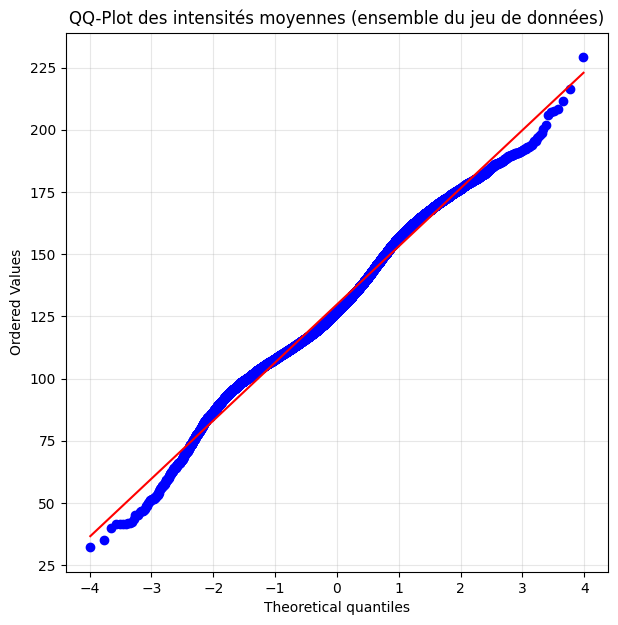

In [16]:
# Test de la normalité des données : QQ-Plot
from scipy import stats
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

stats.probplot(
    df_images["pixel_mean"],
    dist="norm",
    plot=plt
)

plt.title("QQ-Plot des intensités moyennes (ensemble du jeu de données)")
plt.grid(alpha=0.3)

plt.show()

Le QQ-Plot met en évidence une déviation de la distribution par rapport à la normalité, notamment aux extrémités, suggérant une distribution non normale des intensités moyennes.

In [19]:
# Test de normalité d'Agostino-Pearson

stat, p_value = normaltest(df_images["pixel_mean"])

print(f"Statistique du test : {stat:.4f}")
print(f"p-value : {p_value:.4e}")

alpha = 0.05

if p_value < alpha:
    print("Conclusion : la distribution ne suit pas une loi normale (H0 rejetée).")
else:
    print("Conclusion : aucune preuve de non-normalité (H0 non rejetée).")

Statistique du test : 76.7119
p-value : 2.1990e-17
Conclusion : la distribution ne suit pas une loi normale (H0 rejetée).


La très faible p-value (2,20 × 10⁻¹⁷) conduit au rejet de l'hypothèse de normalité. Ce résultat, cohérent avec les observations du QQ-Plot, justifie l'utilisation de tests statistiques non paramétriques (Kruskal-Wallis puis test post-hoc de Dunn) pour comparer les distributions entre les différentes classes.

Il est nécessaire de compléter cette analyse globale par une distribution par classe.

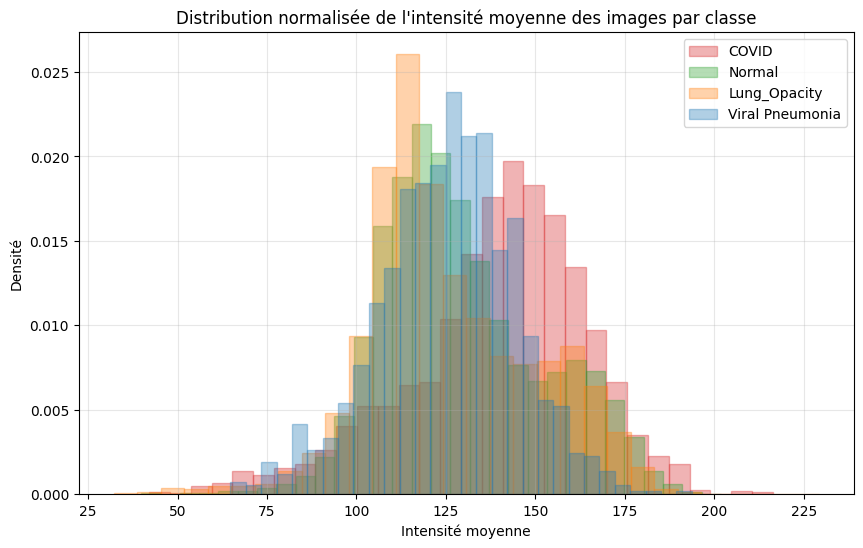

In [20]:
# Distribution des intensités moyennes des pixels par classe

colors = {
    "COVID": "#d62728",           
    "Normal": "#2ca02c",          
    "Lung_Opacity": "#ff7f0e",    
    "Viral Pneumonia": "#1f77b4"  
}

plt.figure(figsize=(10, 6))

for class_name in classes:
    
    subset = df_images[df_images["classe"] == class_name]
    
    plt.hist(
        subset["pixel_mean"],
        bins=30,
        density=True,
        alpha=0.35,                    
        color=colors[class_name],
        edgecolor=colors[class_name],
        label=class_name
    )

plt.title("Distribution normalisée de l'intensité moyenne des images par classe")
plt.xlabel("Intensité moyenne")
plt.ylabel("Densité")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Les distributions des intensités moyennes présentent un fort chevauchement entre les quatre classes, indiquant que cette caractéristique seule ne permet pas de les discriminer clairement. Néanmoins, les images de la classe COVID apparaissent globalement décalées vers des intensités moyennes plus élevées, tandis que les classes Lung_Opacity et Viral Pneumonia sont davantage concentrées autour de valeurs plus faibles.

##### Boxplots

C:\Users\n_a_e\AppData\Local\Temp\ipykernel_37188\2420514113.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


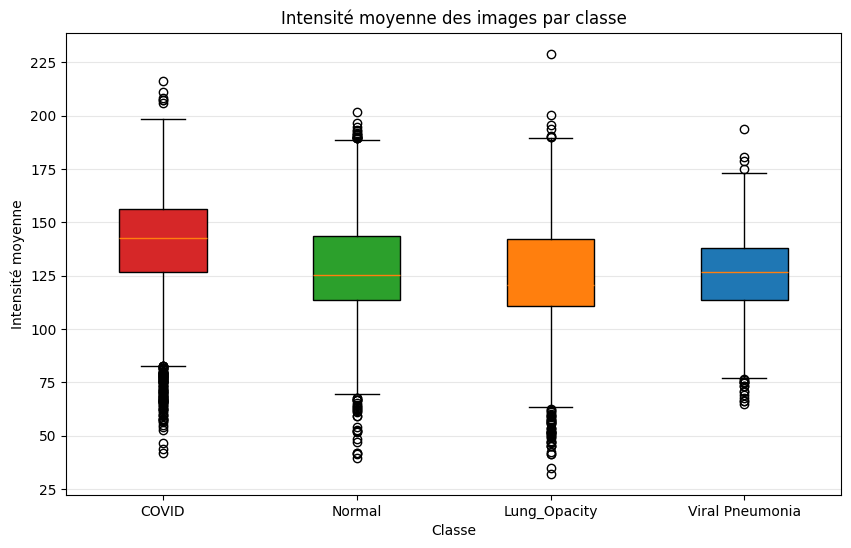

In [24]:
colors = {
    "COVID": "#d62728",           
    "Normal": "#2ca02c",        
    "Lung_Opacity": "#ff7f0e",    
    "Viral Pneumonia": "#1f77b4" 
}

data_to_plot = [
    df_images[df_images["classe"] == class_name]["pixel_mean"]
    for class_name in classes
]

fig, ax = plt.subplots(figsize=(10, 6))

box = ax.boxplot(
    data_to_plot,
    patch_artist=True,
    labels=classes
)

# Application des couleurs
for patch, class_name in zip(box['boxes'], classes):
    patch.set_facecolor(colors[class_name])

plt.title("Intensité moyenne des images par classe")
plt.xlabel("Classe")
plt.ylabel("Intensité moyenne")
plt.grid(axis="y", alpha=0.3)

plt.show()

Ce boxplot montre de nombreux outliers, des distributions asymétriques, et des variances visiblement différentes selon les classes. Il convient de réaliser un test de comparaison des moyennes entre les 4 classes. Au regard des tendances observées et de la non normalité des données, une ANOVA n'est pas réalisable, un test de Kruskal-Wallis est plus approprié.

In [25]:
# Confirmation des tendances par test Kruskal-Wallis

# H0 : Les distributions de pixel_mean sont identiques dans les 4 classes.
# H : Les distributions de pixel_mean ne sont pas identiques dans les 4 classes.

covid = df_images.query("classe=='COVID'")["pixel_mean"]
normal = df_images.query("classe=='Normal'")["pixel_mean"]
lung = df_images.query("classe=='Lung_Opacity'")["pixel_mean"]
viral = df_images.query("classe=='Viral Pneumonia'")["pixel_mean"]

H, p = kruskal(
    covid,
    normal,
    lung,
    viral
)

print("H =", H)
print("p =", p)

H = 926.4912029140867
p = 1.5878893213258662e-200


La statistique H de Kruskal-Wallis mesure à quel point les distributions des groupes sont différentes. Ici elle est très élevée. Celà signifie que les ordres de grandeur des observations diffèrent fortement entre les groupes.

La p-value est ici fortement inférieure à 0.05. On rejette donc H0 avec un risque alpha=5% de se tromper. L'intensité moyenne des images n'est pas identique entre les quatre classes étudiées. Au moins une classe diffère des autres. Pour savoir lesquelles diffèrent, il faut faire le test post-hoc de Dunn.

In [26]:
# Test de Dunn :
# H0 : les distributions de pixel_mean sont identiques
# H1 : les distributions de pixel_mean sont différentes

dunn_results = sp.posthoc_dunn(
    df_images,
    val_col="pixel_mean",
    group_col="classe",
    p_adjust="bonferroni"
)

dunn_results

,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,1.000000e+00,1.145692e-189,1.013675e-132,1.536931e-74
Lung_Opacity,1.145692e-189,1.000000e+00,3.571060e-18,1.000000e+00
Normal,1.013675e-132,3.571060e-18,1.000000e+00,1.950841e-03
Viral Pneumonia,1.536931e-74,1.000000e+00,1.950841e-03,1.000000e+00


Pour chaque p-value < 0.05 on rejette H0 avec un risque alpha = 5% de se tromper.

Avec des p-values fortement inférieures à 0.05 à chaque comparaison, seule la classe COVID est clairement différente des 3 autres classes.

Lung_Opacity et Viral Pneumonia sont indiscernables : fusionner ces 2 classes ?

La classe Normale aussi a des p-values inférieures à 0.05 à chaque comparaison, mais moins fortes que celles de la classe COVID, notamment avec Viral Pneumonia

Au regard de la quantité des données, il existe un risque d'amplification statistique de faibles différences. Il est donc judicieux de procéder une mesure de taille d'effet.

In [27]:
N = len(df_images)

eta2 = (H - len(classes) + 1) / (N - len(classes))
print(eta2)

0.04433254298469044


L'eta2 mesure la taille de l'effet, c'est-à-dire la proportion de la variabilité de la variable étudiée. Ici 4,65 % de la variabilité de l'intensité moyenne des images est expliquée par la classification, ce qui est assez faible. Celà peut s'expliquer par le fort chevauchement des données.

En croisant les différentes approches statistiques et les analyses graphiques, il apparait que l'intensité moyenne des pixelx contient une information discriminante vis-à-vis de la classe COVID, mais sont effet discriminant est atténué par la forte dispersion des données. Il faudrait envisager d'autres variables à exploiter, ainsi qu'une réduction de cette dispersion notamment par suppression des outliers.

##### Intensité des pixels par image

In [28]:
# Sélection d'un échantillon d'images

import random
from pathlib import Path

random.seed(42)

selected_images = {}

for class_name in classes:
    images_dir = data_path / class_name / "images"
    image_files = sorted(list(images_dir.glob("*.png")))
    
    selected_images[class_name] = random.sample(image_files, 10)

for class_name, image_paths in selected_images.items():
    print(f"\n{class_name}")
    for img_path in image_paths:
        print(img_path.name)


COVID
COVID-3502.png
COVID-1479.png
COVID-1093.png
COVID-673.png
COVID-2098.png
COVID-1987.png
COVID-1906.png
COVID-1589.png
COVID-654.png
COVID-1432.png

Normal
Normal-8914.png
Normal-2111.png
Normal-9582.png
Normal-7078.png
Normal-1294.png
Normal-1265.png
Normal-2211.png
Normal-4066.png
Normal-4274.png
Normal-8320.png

Lung_Opacity
Lung_Opacity-5456.png
Lung_Opacity-1194.png
Lung_Opacity-5155.png
Lung_Opacity-2469.png
Lung_Opacity-888.png
Lung_Opacity-5809.png
Lung_Opacity-78.png
Lung_Opacity-5035.png
Lung_Opacity-4103.png
Lung_Opacity-2629.png

Viral Pneumonia
Viral Pneumonia-62.png
Viral Pneumonia-88.png
Viral Pneumonia-303.png
Viral Pneumonia-101.png
Viral Pneumonia-1294.png
Viral Pneumonia-570.png
Viral Pneumonia-418.png
Viral Pneumonia-1287.png
Viral Pneumonia-186.png
Viral Pneumonia-411.png


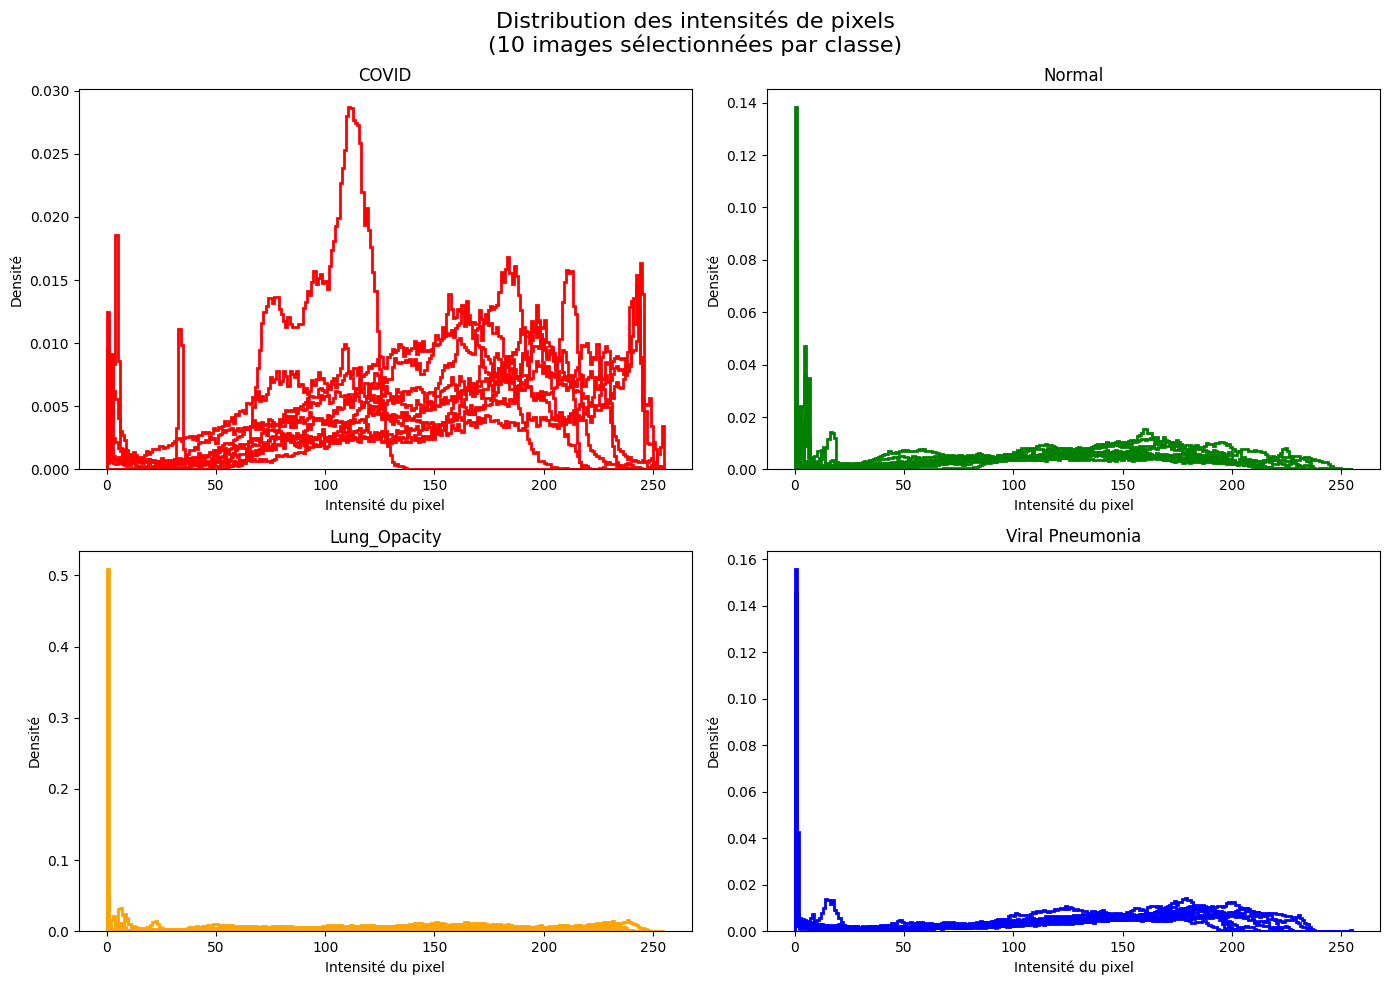

In [29]:
# Distribution des intensités de chaque pixel sur un échantillon d'images

colors = {
    "COVID": "red",
    "Normal": "green",
    "Lung_Opacity": "orange",
    "Viral Pneumonia": "blue"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, class_name in enumerate(classes):
    
    for i, img_path in enumerate(selected_images[class_name]):
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        
        axes[idx].hist(
            img.ravel(),
            bins=256,
            range=(0, 255),
            density=True,
            histtype="step",
            linewidth=2,
            color=colors[class_name],
            label=f"Image {i+1}"
        )
    
    axes[idx].set_title(class_name)
    axes[idx].set_xlabel("Intensité du pixel")
    axes[idx].set_ylabel("Densité")

plt.suptitle(
    "Distribution des intensités de pixels\n"
    "(10 images sélectionnées par classe)",
    fontsize=16
)

plt.tight_layout()
plt.show()

Les profils de distribution des intensités présentent une forte variabilité intra-classe et un important chevauchement entre les différentes classes. Toutes les classes montrent une concentration de pixels de faible intensité, correspondant aux zones sombres des radiographies. Ces observations suggèrent que la distribution globale des niveaux de gris, prise isolément, ne constitue pas une caractéristique suffisamment discriminante pour distinguer les différentes pathologies.

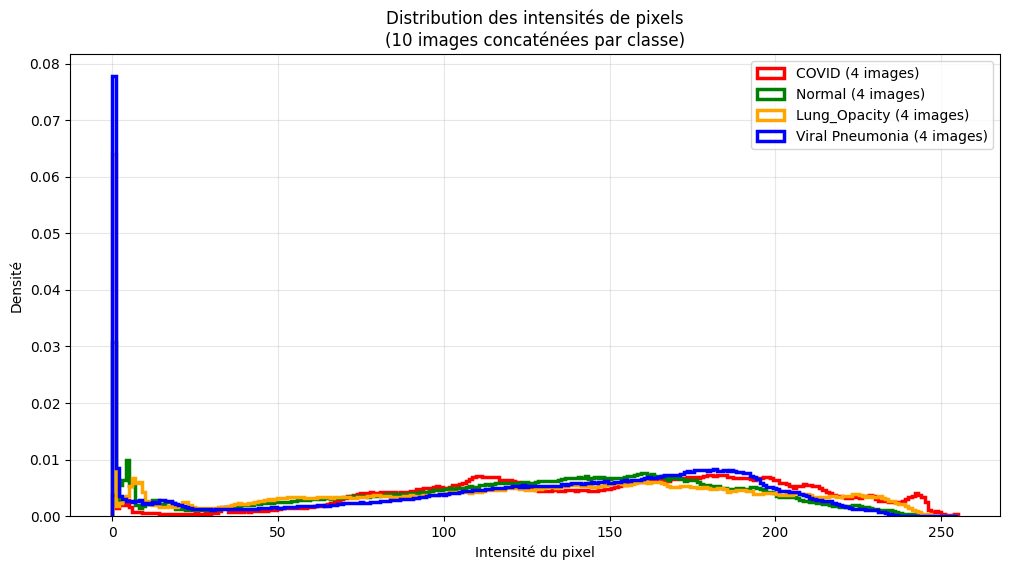

In [30]:
# Distribution des intensités de chaque pixel sur un échantillon d'images (concaténation des images par classe)

colors = {
    "COVID": "red",
    "Normal": "green",
    "Lung_Opacity": "orange",
    "Viral Pneumonia": "blue"
}

plt.figure(figsize=(12, 6))

for class_name in classes:

    pixels = []

    for img_path in selected_images[class_name]:

        img = cv2.imread(
            str(img_path),
            cv2.IMREAD_GRAYSCALE
        )

        pixels.extend(img.ravel())

    pixels = np.array(pixels)

    plt.hist(
        pixels,
        bins=256,
        range=(0, 255),
        density=True,
        histtype="step",
        linewidth=2.5,
        color=colors[class_name],
        label=f"{class_name} (4 images)"
    )

plt.title(
    "Distribution des intensités de pixels\n"
    "(10 images concaténées par classe)"
)

plt.xlabel("Intensité du pixel")
plt.ylabel("Densité")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Les distributions des intensités de pixels se recouvrent largement entre les classes, suggérant que cette caractéristique seule ne permet pas de discriminer les différentes pathologies.

#### Ecart type de l'intensité des pixels

##### Distribution et normalité

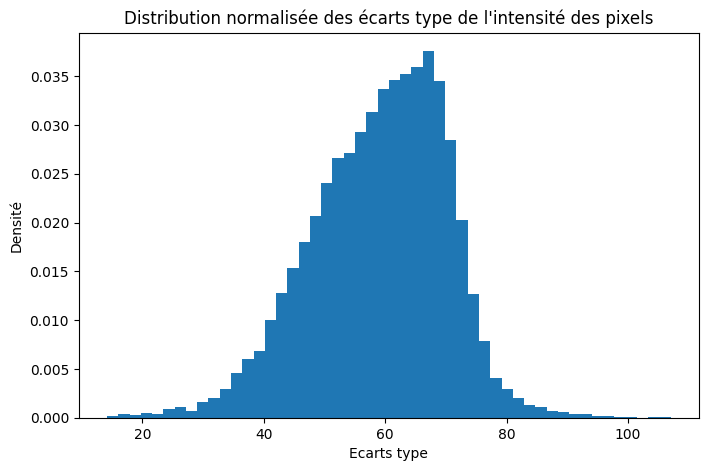

In [12]:
# Distribution des écart types des pixels

plt.figure(figsize=(8, 5))
plt.hist(df_images["pixel_std"], bins=50, density=True,)
plt.title("Distribution normalisée des écarts type de l'intensité des pixels")
plt.xlabel("Ecarts type")
plt.ylabel("Densité")
plt.show()

La distribution est là aussi asymétrique mais la non normalité semble moins marquée que pour l'intensité moyennes. Un test de normalité doit être réalisé.

In [33]:
# Test d'Agostino Pearson

stat, p_value = normaltest(df_images["pixel_std"])

print(f"Statistique du test : {stat:.4f}")
print(f"p-value : {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion : la distribution ne suit pas une loi normale (H0 rejetée).")
else:
    print("Conclusion : aucune preuve de non-normalité (H0 non rejetée).")

Statistique du test : 573.9871
p-value : 2.2923e-125
Conclusion : la distribution ne suit pas une loi normale (H0 rejetée).


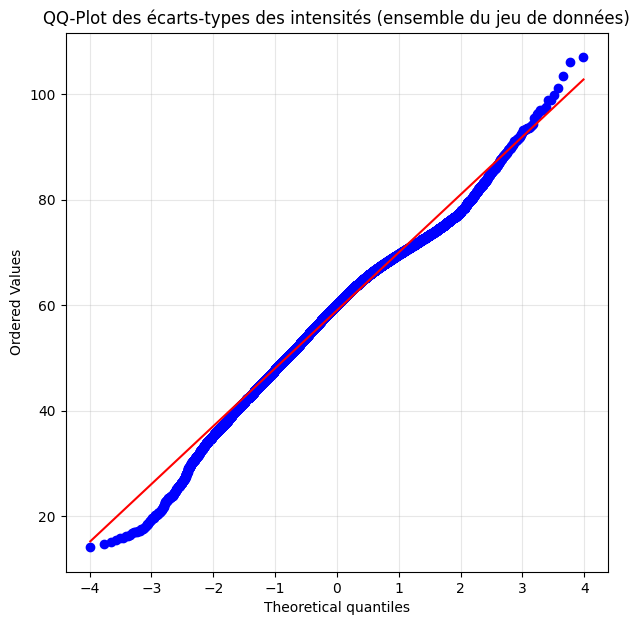

In [35]:
from scipy import stats
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

stats.probplot(
    df_images["pixel_std"],
    dist="norm",
    plot=plt
)

plt.title("QQ-Plot des écarts-types des intensités (ensemble du jeu de données)")
plt.grid(alpha=0.3)

plt.show()

la non normalité est confirmée statistiquement et graphiquement.

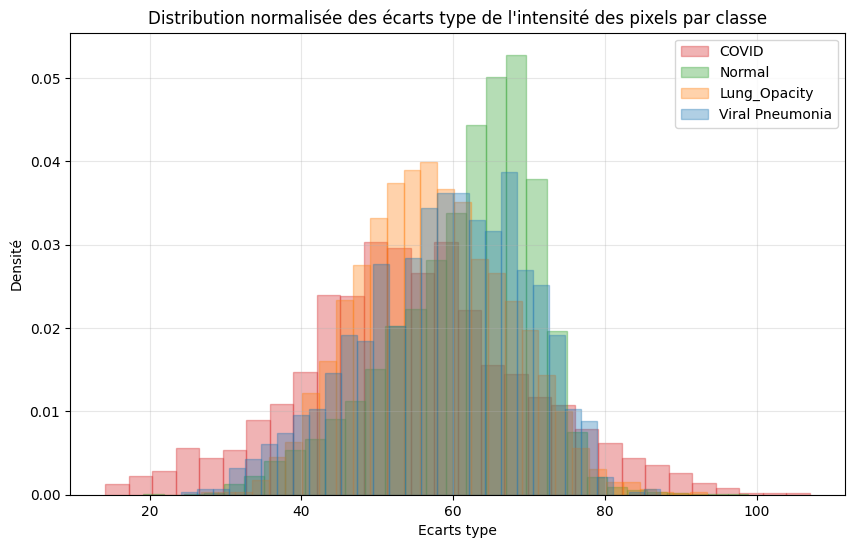

In [36]:
colors = {
    "COVID": "#d62728",           
    "Normal": "#2ca02c",          
    "Lung_Opacity": "#ff7f0e",    
    "Viral Pneumonia": "#1f77b4"  
}

plt.figure(figsize=(10, 6))

for class_name in classes:
    
    subset = df_images[df_images["classe"] == class_name]
    
    plt.hist(
        subset["pixel_std"],
        bins=30,
        density=True,
        alpha=0.35,                    
        color=colors[class_name],
        edgecolor=colors[class_name],
        label=class_name
    )

plt.title("Distribution normalisée des écarts type de l'intensité des pixels par classe")
plt.xlabel("Ecarts type")
plt.ylabel("Densité")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Les distributions des écarts-types présentent un fort chevauchement entre les quatre classes, suggérant que le contraste global des images ne constitue pas, à lui seul, un critère discriminant pour différencier les pathologies.

##### Boxplots

C:\Users\n_a_e\AppData\Local\Temp\ipykernel_37188\1953784469.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


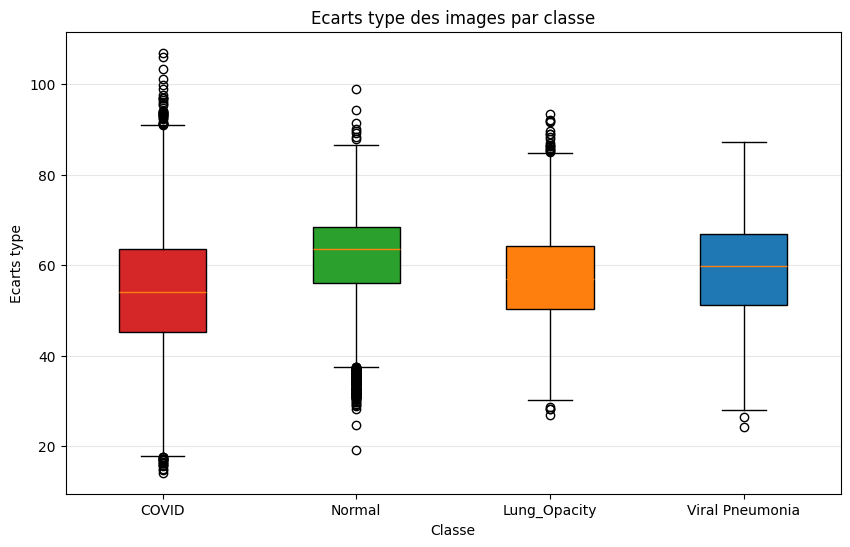

In [37]:
colors = {
    "COVID": "#d62728",           
    "Normal": "#2ca02c",        
    "Lung_Opacity": "#ff7f0e",    
    "Viral Pneumonia": "#1f77b4" 
}

data_to_plot = [
    df_images[df_images["classe"] == class_name]["pixel_std"]
    for class_name in classes
]

fig, ax = plt.subplots(figsize=(10, 6))

box = ax.boxplot(
    data_to_plot,
    patch_artist=True,
    labels=classes
)

# Application des couleurs
for patch, class_name in zip(box['boxes'], classes):
    patch.set_facecolor(colors[class_name])

plt.title("Ecarts type des images par classe")
plt.xlabel("Classe")
plt.ylabel("Ecarts type")
plt.grid(axis="y", alpha=0.3)

plt.show()

Les quatre classes présentent des distributions d'écarts-types largement superposées, malgré de légères différences de médiane et la présence de valeurs aberrantes.

In [39]:
# Confirmation des tendances par test Kruskal-Wallis

# H0 : Les distributions de pixel_std sont identiques dans les 4 classes.
# H : Les distributions de pixel_std ne sont pas identiques dans les 4 classes.

covid = df_images.query("classe=='COVID'")["pixel_std"]
normal = df_images.query("classe=='Normal'")["pixel_std"]
lung = df_images.query("classe=='Lung_Opacity'")["pixel_std"]
viral = df_images.query("classe=='Viral Pneumonia'")["pixel_std"]

H, p = kruskal(
    covid,
    normal,
    lung,
    viral
)

print("H =", H)
print("p =", p)

H = 1339.049773304294
p = 4.9510649034203955e-290


On confirme les résultats obtenus pour pixel_mean.

In [40]:
# Test de Dunn :
# H0 : les distributions de pixel_std sont identiques
# H1 : les distributions de pixel_std sont différentes

dunn_results = sp.posthoc_dunn(
    df_images,
    val_col="pixel_std",
    group_col="classe",
    p_adjust="bonferroni"
)

dunn_results

,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,1.000000e+00,7.105038e-13,7.352058e-210,5.305965e-26
Lung_Opacity,7.105038e-13,1.000000e+00,1.921258e-171,4.235461e-09
Normal,7.352058e-210,1.921258e-171,1.000000e+00,1.142677e-19
Viral Pneumonia,5.305965e-26,4.235461e-09,1.142677e-19,1.000000e+00


Contrairement à la l'intensité moyenne, l'écartype permet de différencier Lung_Opacity et Viral Pneumonia.Différence plus accentuée entre Normal et Viral Pneumonia. Même tendance pour le reste.

## 5. Caractéristiques des masks

### 5.1 Qualité des données

In [41]:
mask_infos = []

for class_name in classes:
    masks_dir = data_path / class_name / "masks"
    
    for mask_path in masks_dir.glob("*.png"):
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        
        if mask is None:
            mask_infos.append({
                "classe": class_name,
                "fichier": mask_path.name,
                "erreur_lecture": True
            })
            continue
        
        height, width = mask.shape
        mask_area = np.sum(mask > 0)
        total_area = width * height
        mask_ratio = mask_area / total_area
        
        mask_infos.append({
            "classe": class_name,
            "fichier": mask_path.name,
            "largeur": width,
            "hauteur": height,
            "surface_mask": mask_area,
            "surface_totale": total_area,
            "proportion_mask": mask_ratio,
            "pixel_min": mask.min(),
            "pixel_max": mask.max(),
            "erreur_lecture": False
        })

df_masks = pd.DataFrame(mask_infos)
df_masks.head()

,classe,fichier,largeur,hauteur,surface_mask,surface_totale,proportion_mask,pixel_min,pixel_max,erreur_lecture
0,COVID,COVID-1.png,256,256,15359,65536,0.234360,0,255,False
1,COVID,COVID-10.png,256,256,17225,65536,0.262833,0,255,False
2,COVID,COVID-1000.png,256,256,16121,65536,0.245987,0,255,False
3,COVID,COVID-1001.png,256,256,9726,65536,0.148407,0,255,False
4,COVID,COVID-1002.png,256,256,27828,65536,0.424622,0,255,False


In [22]:
df_masks.shape

(21165, 10)

In [47]:
df_masks.describe()

,largeur,hauteur,surface_mask,surface_totale,proportion_mask,pixel_min,pixel_max
count,20835.0,20835.0,20835.000000,20835.0,20835.000000,20835.0,20835.0
mean,256.0,256.0,15653.467531,65536.0,0.238853,0.0,255.0
std,0.0,0.0,4026.779827,0.0,0.061444,0.0,0.0
min,256.0,256.0,1901.000000,65536.0,0.029007,0.0,255.0
25%,256.0,256.0,12851.000000,65536.0,0.196091,0.0,255.0
50%,256.0,256.0,15423.000000,65536.0,0.235336,0.0,255.0
75%,256.0,256.0,18180.500000,65536.0,0.277412,0.0,255.0
max,256.0,256.0,38028.000000,65536.0,0.580261,0.0,255.0


In [48]:
df_masks.groupby("classe")[["surface_mask", "proportion_mask"]].agg(["min", "max", "mean", "std"])

surface_mask                                    \
                         min    max          mean          std   
classe                                                           
COVID                   4087  38028  15865.059294  4698.918860   
Lung_Opacity            1901  29445  14124.435037  3626.954053   
Normal                  3323  30098  16535.154006  3813.167557   
Viral Pneumonia         6666  30437  15283.791480  3353.196013   

                proportion_mask                                
                            min       max      mean       std  
classe                                                         
COVID                  0.062363  0.580261  0.242082  0.071700  
Lung_Opacity           0.029007  0.449295  0.215522  0.055343  
Normal                 0.050705  0.459259  0.252306  0.058184  
Viral Pneumonia        0.101715  0.464432  0.233212  0.051166

Aucune anomalie détectée sur l'intégrité des données et la présence des fichiers.

### 5.2 Statistiques exploratoires

La proportion du masque correspond à la fraction de l'image occupée par la région pulmonaire délimitée par le masque de segmentation. Elle renseigne sur la surface relative des poumons dans l'image et permet d'évaluer l'homogénéité du cadrage et de la segmentation entre les radiographies.

#### Distribution et normalité

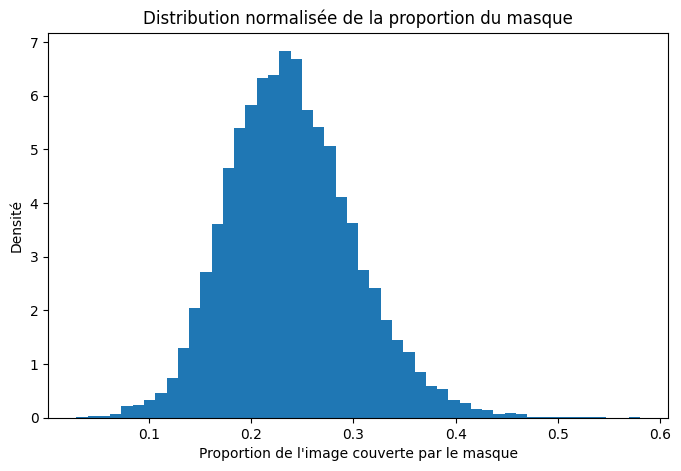

In [25]:
plt.figure(figsize=(8, 5))
plt.hist(df_masks["proportion_mask"], bins=50, density=True)
plt.title("Distribution normalisée de la proportion du masque")
plt.xlabel("Proportion de l'image couverte par le masque")
plt.ylabel("Densité")
plt.show()

La distribution est unimodale et centrée autour de 24 % de la surface de l'image, indiquant que les poumons occupent une proportion relativement constante des radiographies. La faible dispersion observée suggère une bonne homogénéité des masques de segmentation à l'échelle du jeu de données.

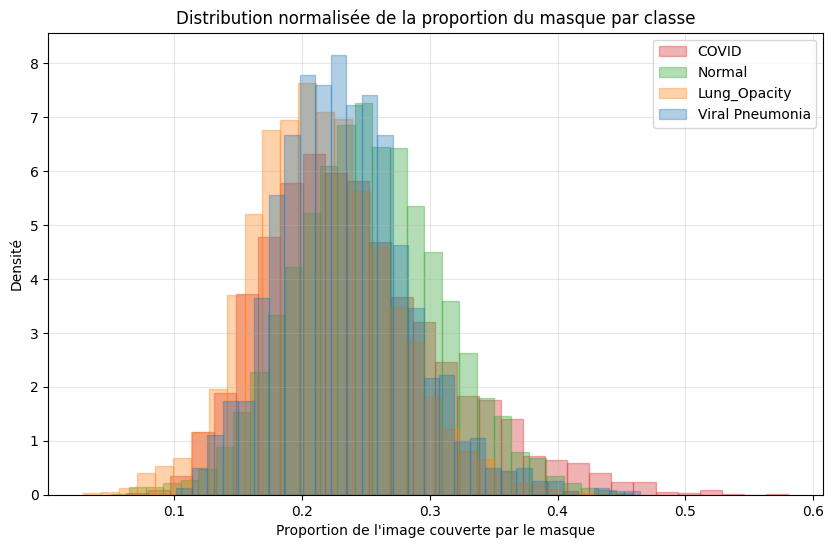

In [46]:
colors = {
    "COVID": "#d62728",           
    "Normal": "#2ca02c",          
    "Lung_Opacity": "#ff7f0e",    
    "Viral Pneumonia": "#1f77b4"  
}

plt.figure(figsize=(10, 6))

for class_name in classes:
    
    subset = df_masks[df_masks["classe"] == class_name]
    
    plt.hist(
        subset["proportion_mask"],
        bins=30,
        density=True,
        alpha=0.35,                    
        color=colors[class_name],
        edgecolor=colors[class_name],
        label=class_name
    )

plt.title("Distribution normalisée de la proportion du masque par classe")
plt.xlabel("Proportion de l'image couverte par le masque")
plt.ylabel("Densité")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Les proportions de masque sont globalement similaires entre les classes, avec un fort recouvrement des distributions et une légère dispersion plus importante pour la classe COVID.

In [50]:
from scipy.stats import normaltest

valeurs = df_masks["proportion_mask"].dropna()

stat, p_value = normaltest(valeurs)

print(f"Statistique du test : {stat:.4f}")
print(f"p-value : {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion : la distribution ne suit pas une loi normale (H0 rejetée).")
else:
    print("Conclusion : aucune preuve de non-normalité (H0 non rejetée).")

Statistique du test : 527.9455
p-value : 2.2809e-115
Conclusion : la distribution ne suit pas une loi normale (H0 rejetée).


La non normalité est confirmée

#### Boxplots

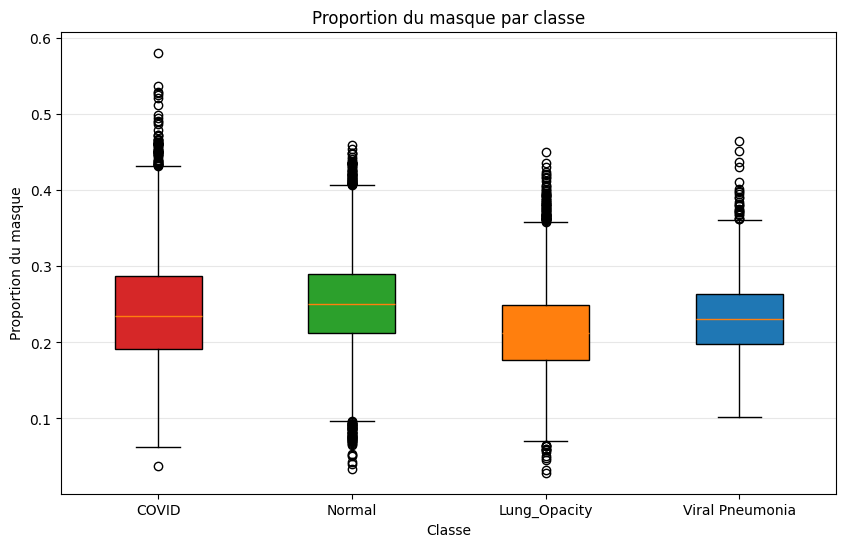

In [27]:
colors = {
    "COVID": "#d62728",
    "Normal": "#2ca02c",
    "Lung_Opacity": "#ff7f0e",
    "Viral Pneumonia": "#1f77b4"
}

data_to_plot = [
    df_masks[df_masks["classe"] == class_name]["proportion_mask"]
    for class_name in classes
]

fig, ax = plt.subplots(figsize=(10, 6))

box = ax.boxplot(
    data_to_plot,
    patch_artist=True,
    tick_labels=classes
)

# Application des couleurs
for patch, class_name in zip(box['boxes'], classes):
    patch.set_facecolor(colors[class_name])

plt.title("Proportion du masque par classe")
plt.xlabel("Classe")
plt.ylabel("Proportion du masque")
plt.grid(axis="y", alpha=0.3)

plt.show()

Les proportions de masque sont globalement comparables entre les quatre classes, avec un fort chevauchement des distributions. Malgré de légères différences de médiane et quelques valeurs aberrantes, la surface occupée par les poumons reste homogène d'une classe à l'autre.

In [55]:
# Données par classe
covid = df_masks.loc[df_masks["classe"] == "COVID", "proportion_mask"]
normal = df_masks.loc[df_masks["classe"] == "Normal", "proportion_mask"]
lung = df_masks.loc[df_masks["classe"] == "Lung_Opacity", "proportion_mask"]
viral = df_masks.loc[df_masks["classe"] == "Viral Pneumonia", "proportion_mask"]

# Test de Kruskal-Wallis
stat, p_value = kruskal(covid, normal, lung, viral)

print(f"Statistique du test : {stat:.4f}")
print(f"p-value : {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion : au moins une classe diffère significativement.")
else:
    print("Conclusion : aucune différence significative entre les classes.")

Statistique du test : 1513.9375
p-value : 0.0000e+00
Conclusion : au moins une classe diffère significativement.


Bien que le test de Kruskal-Wallis révèle une différence statistiquement significative entre les classes, les distributions présentent un fort chevauchement et des médianes proches. Cette significativité est probablement amplifiée par la taille importante de l'échantillon et ne traduit pas nécessairement une différence d'ampleur suffisante pour constituer un critère discriminant en pratique.

In [56]:
dunn = sp.posthoc_dunn(
    df_masks,
    val_col="proportion_mask",
    group_col="classe",
    p_adjust="bonferroni"
)

dunn

,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,1.000000e+00,6.474246e-66,2.697043e-38,1.140189e-01
Lung_Opacity,6.474246e-66,1.000000e+00,0.000000e+00,8.517860e-22
Normal,2.697043e-38,0.000000e+00,1.000000e+00,4.881721e-30
Viral Pneumonia,1.140189e-01,8.517860e-22,4.881721e-30,1.000000e+00


Le test de Dunn montre que la plupart des classes présentent des différences significatives de proportion du masque. Toutefois, les classes COVID et Viral Pneumonia ne diffèrent pas significativement (p = 0,114), ce qui confirme la forte proximité observée sur les distributions. Malgré ces différences statistiques, les boxplots mettent en évidence un important chevauchement entre les classes, suggérant que la proportion du masque ne constitue pas un critère discriminant suffisant à elle seule.

## 5. Visualisations

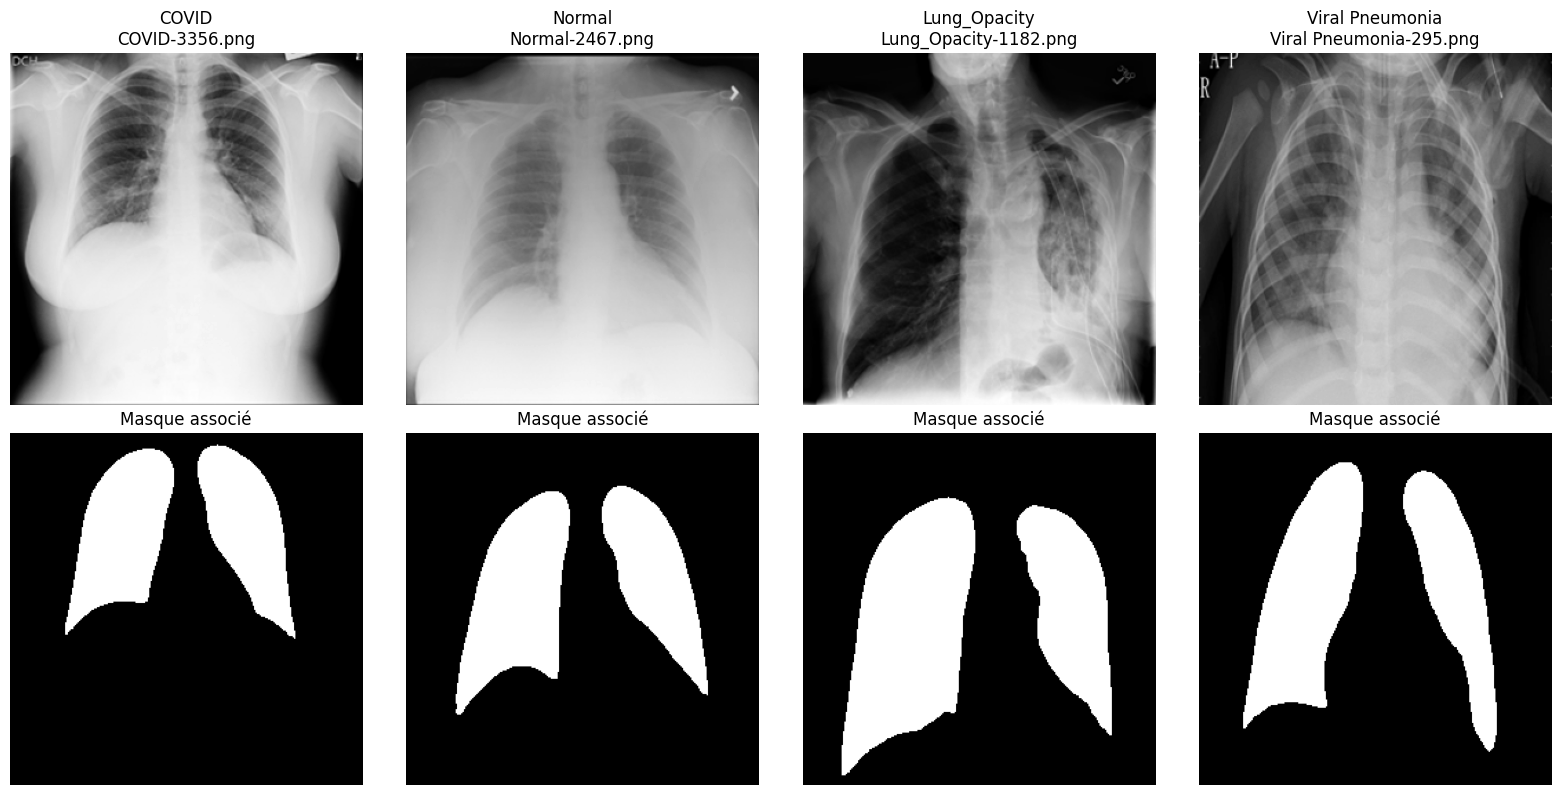

In [28]:
# Images brutes et masks associés

random.seed(42)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, class_name in enumerate(classes):
    images_dir = data_path / class_name / "images"
    masks_dir = data_path / class_name / "masks"
    
    image_files = list(images_dir.glob("*.png"))
    img_path = random.choice(image_files)
    mask_path = masks_dir / img_path.name
    
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    
    axes[0, idx].imshow(img, cmap="gray")
    axes[0, idx].set_title(f"{class_name}\n{img_path.name}")
    axes[0, idx].axis("off")
    
    axes[1, idx].imshow(mask, cmap="gray")
    axes[1, idx].set_title("Masque associé")
    axes[1, idx].axis("off")

plt.tight_layout()
plt.show()

## 6. Application des masks après redimensionnement

COVID
Image : COVID-3356.png (299, 299)
Masque : COVID-3356.png (256, 256)
Normal
Image : Normal-2467.png (299, 299)
Masque : Normal-2467.png (256, 256)
Lung_Opacity
Image : Lung_Opacity-1182.png (299, 299)
Masque : Lung_Opacity-1182.png (256, 256)
Viral Pneumonia
Image : Viral Pneumonia-295.png (299, 299)
Masque : Viral Pneumonia-295.png (256, 256)


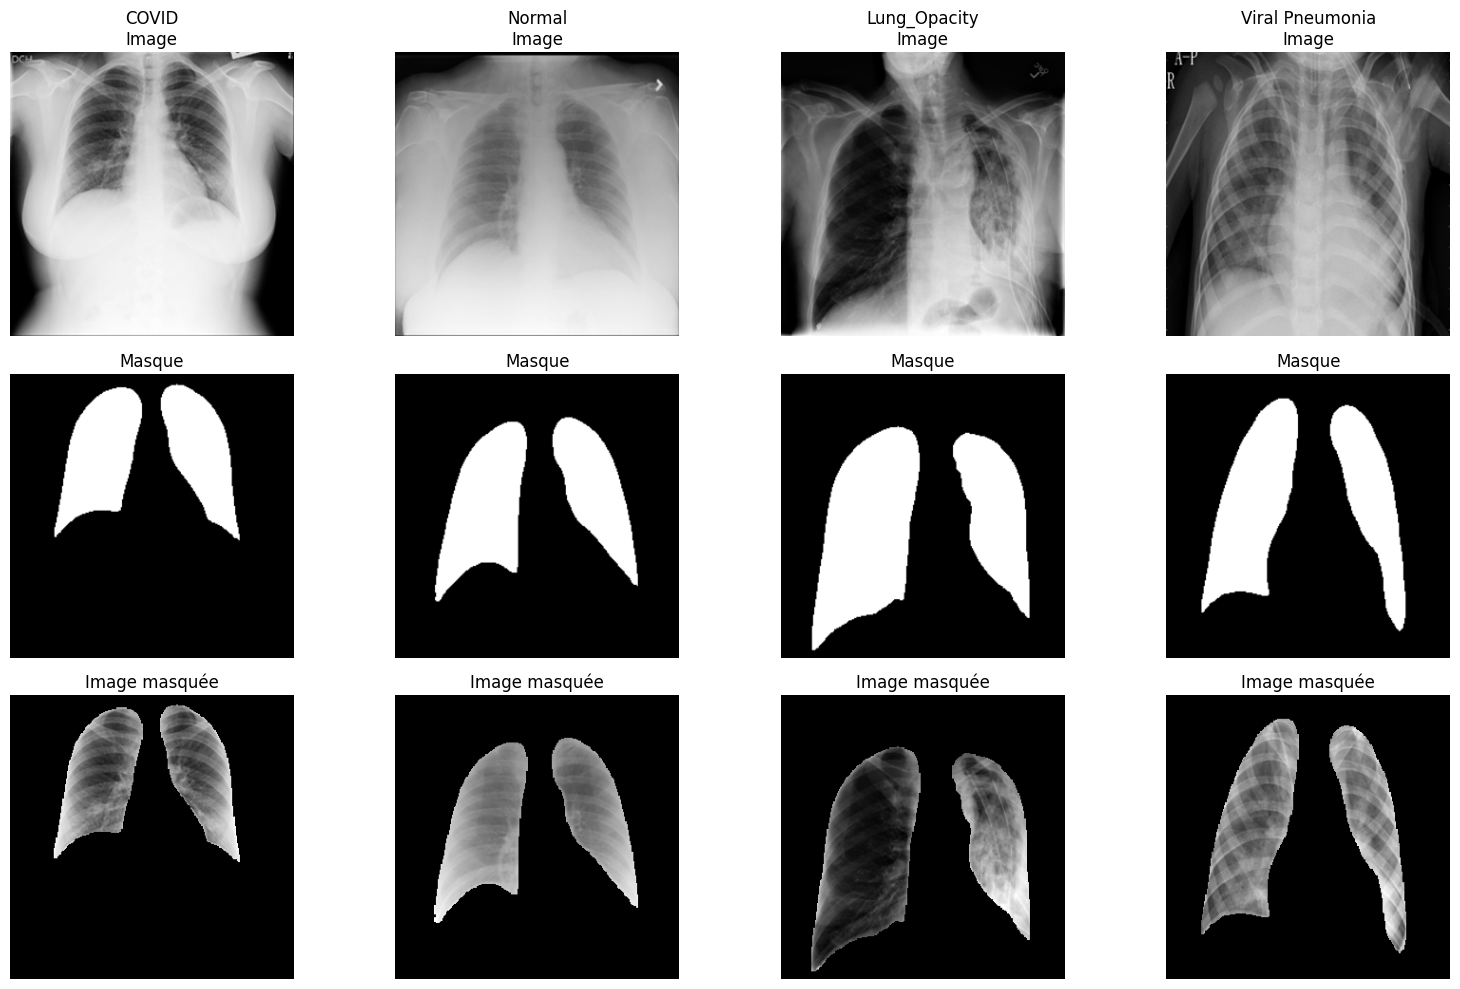

In [31]:
random.seed(42)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for idx, class_name in enumerate(classes):
    images_dir = data_path / class_name / "images"
    masks_dir = data_path / class_name / "masks"

    img_path = random.choice(list(images_dir.glob("*.png")))
    mask_path = masks_dir / img_path.name

    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    # Vérification
    print(class_name)
    print("Image :", img_path.name, img.shape)
    print("Masque :", mask_path.name, mask.shape)

    # Redimensionner le masque si nécessaire
    if img.shape != mask.shape:
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]))

    # S'assurer que le masque est bien en uint8
    mask = mask.astype(np.uint8)

    masked_img = cv2.bitwise_and(img, img, mask=mask)

    axes[0, idx].imshow(img, cmap="gray")
    axes[0, idx].set_title(f"{class_name}\nImage")
    axes[0, idx].axis("off")

    axes[1, idx].imshow(mask, cmap="gray")
    axes[1, idx].set_title("Masque")
    axes[1, idx].axis("off")

    axes[2, idx].imshow(masked_img, cmap="gray")
    axes[2, idx].set_title("Image masquée")
    axes[2, idx].axis("off")

plt.tight_layout()
plt.show()

L'application des masques permet de conserver les poumons et donc de supprimer les signaux non désirés ce qui favorisera la performance des modèles.

In [29]:
# Vérification

print("Classe :", class_name)
print("Image :", img_path.name, img.shape)

if mask is None:
    print("Masque non trouvé :", mask_path)
else:
    print("Masque :", mask_path.name, mask.shape)

Classe : Viral Pneumonia
Image : Viral Pneumonia-295.png (299, 299)
Masque : Viral Pneumonia-295.png (256, 256)


In [51]:
# Anomalies

print("Images non lisibles :", df_images["erreur_lecture"].sum())
print("Masques non lisibles :", df_masks["erreur_lecture"].sum())

print("Images avec pixel max = 0 :", (df_images["pixel_max"] == 0).sum())
print("Masques vides :", (df_masks["surface_mask"] == 0).sum())

Images non lisibles : 0
Masques non lisibles : 0
Images avec pixel max = 0 : 0
Masques vides : 0


## 7. Application généralisée des masks - Nouveau répertoire

In [ ]:
# Dossier source
data_path = Path("../../../COVID-19_Radiography_Dataset")

classes = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]

# Dossier de sortie
output_path = Path("../../../COVID-19_Radiography_Dataset_processed")
output_path.mkdir(exist_ok=True)

for class_name in classes:
    
    images_dir = data_path / class_name / "images"
    masks_dir = data_path / class_name / "masks"
    
    output_class_dir = output_path / class_name / "masked_images"
    output_class_dir.mkdir(parents=True, exist_ok=True)
    
    image_files = sorted(images_dir.glob("*.png"))
    
    for img_path in image_files:
        
        mask_path = masks_dir / img_path.name
        
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            print(f"Image non lisible : {img_path}")
            continue
        
        if mask is None:
            print(f"Masque manquant ou non lisible : {mask_path}")
            continue
        
        # Redimensionnement du masque à la taille de l'image
        height, width = img.shape
        
        mask_resized = cv2.resize(
            mask,
            (width, height),
            interpolation=cv2.INTER_NEAREST
        )
        
        # Binarisation du masque : pixels > 0 deviennent 255
        mask_binary = np.where(mask_resized > 0, 255, 0).astype(np.uint8)
        
        # Application du masque
        masked_img = cv2.bitwise_and(img, img, mask=mask_binary)
        
        # Sauvegarde
        output_file = output_class_dir / img_path.name
        cv2.imwrite(str(output_file), masked_img)

print("Traitement terminé.")
print("Images masquées enregistrées dans :", output_path.resolve())

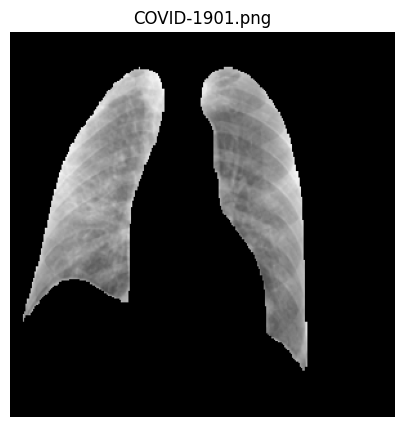

In [34]:
# Vérification

class_name = "COVID"

example_path = random.choice(
    list((Path("../../../COVID-19_Radiography_Dataset_processed") / class_name / "masked_images").glob("*.png"))
)

masked_img = cv2.imread(str(example_path), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5, 5))
plt.imshow(masked_img, cmap="gray")
plt.title(example_path.name)
plt.axis("off")
plt.show()

In [35]:
masked_dir = Path("../../../COVID-19_Radiography_Dataset_processed") / "COVID" / "masked_images"

print(masked_dir)
print(masked_dir.exists())

if masked_dir.exists():
    print(list(masked_dir.iterdir())[:10])

..\..\..\COVID-19_Radiography_Dataset_processed\COVID\masked_images
True
[WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-10.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-100.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1000.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1001.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1002.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1003.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1004.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1005.png'), WindowsPath('../../../COVID-19_Radiograph

## 8. Caractéristiques des images masquées

### 8.1 Qualité des données

In [52]:
processed_path = Path(
    r"C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset_processed"
)

classes = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]

masked_infos = []

for class_name in classes:
    
    images_dir = processed_path / class_name / "masked_images"
    
    for img_path in images_dir.glob("*.png"):
        
        img = cv2.imread(
            str(img_path),
            cv2.IMREAD_GRAYSCALE
        )
        
        if img is None:
            continue
        
        height, width = img.shape
        
        masked_infos.append({
            "classe": class_name,
            "fichier": img_path.name,
            "largeur": width,
            "hauteur": height,
            "nb_pixels": width * height,
            "pixel_min": img.min(),
            "pixel_max": img.max(),
            "pixel_mean": img.mean(),
            "pixel_std": img.std()
        })

df_masked_images = pd.DataFrame(masked_infos)

print(df_masked_images.shape)
df_masked_images.head()

(20835, 9)


,classe,fichier,largeur,hauteur,nb_pixels,pixel_min,pixel_max,pixel_mean,pixel_std
0,COVID,COVID-1.png,299,299,89401,0,186,29.659881,55.333928
1,COVID,COVID-10.png,299,299,89401,0,179,32.049328,55.005081
2,COVID,COVID-1000.png,299,299,89401,0,236,33.070346,62.669766
3,COVID,COVID-1001.png,299,299,89401,0,198,18.744130,46.364107
4,COVID,COVID-1002.png,299,299,89401,0,254,55.004362,68.801125


### 8.2 statistiques exploratoires

#### Intensité moyenne

##### Distribution et normalité

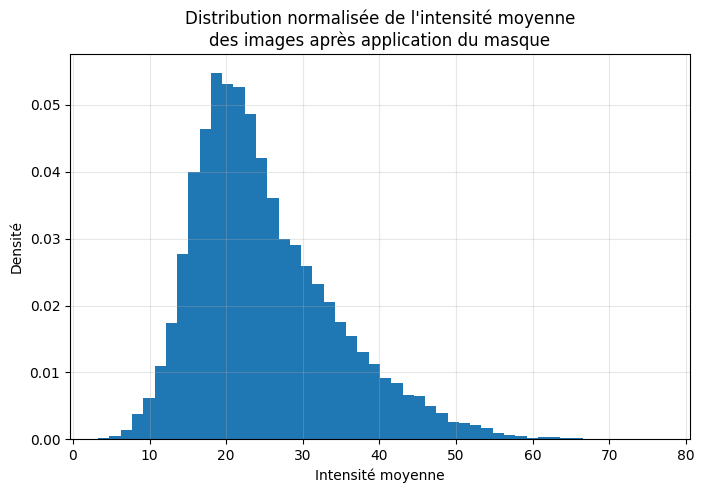

In [57]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_masked_images["pixel_mean"],
    bins=50,
    density=True
)

plt.title(
    "Distribution normalisée de l'intensité moyenne\n"
    "des images après application du masque"
)

plt.xlabel("Intensité moyenne")
plt.ylabel("Densité")

plt.grid(alpha=0.3)

plt.show()

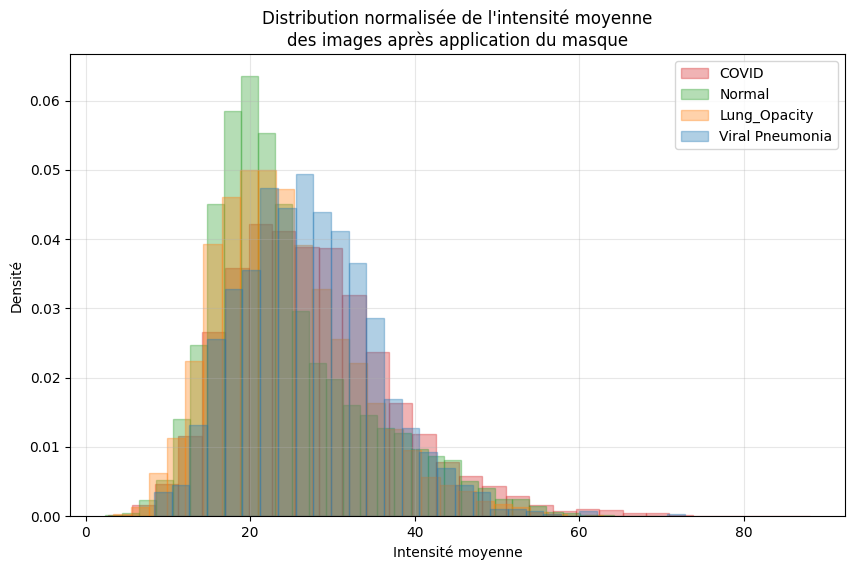

In [39]:
colors = {
    "COVID": "#d62728",
    "Normal": "#2ca02c",
    "Lung_Opacity": "#ff7f0e",
    "Viral Pneumonia": "#1f77b4"
}

plt.figure(figsize=(10, 6))

for class_name in classes:
    
    subset = df_masked_images[
        df_masked_images["classe"] == class_name
    ]
    
    plt.hist(
        subset["pixel_mean"],
        bins=30,
        density=True,
        alpha=0.35,
        color=colors[class_name],
        edgecolor=colors[class_name],
        label=class_name
    )

plt.title(
    "Distribution normalisée de l'intensité moyenne\n"
    "des images après application du masque"
)

plt.xlabel("Intensité moyenne")
plt.ylabel("Densité")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

L'application du masque réduit l'influence de l'arrière-plan mais ne permet pas de distinguer clairement les classes à partir de l'intensité moyenne des pixels, en raison du fort chevauchement des distributions.

In [58]:
# Test de normalité de D'Agostino-Pearson
# sur l'intensité moyenne après application du masque
valeurs = df_masked_images["pixel_mean"].dropna()

stat, p_value = normaltest(valeurs)

print(f"Statistique du test : {stat:.4f}")
print(f"p-value : {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion : la distribution ne suit pas une loi normale (H0 rejetée).")
else:
    print("Conclusion : aucune preuve de non-normalité (H0 non rejetée).")

Statistique du test : 2602.7934
p-value : 0.0000e+00
Conclusion : la distribution ne suit pas une loi normale (H0 rejetée).


Le test de D'Agostino-Pearson met en évidence une déviation significative par rapport à la normalité (statistique = 2602,79 ; p-value < 0,001). L'hypothèse de normalité est donc rejetée, indiquant que la distribution des intensités moyennes des images après application du masque ne suit pas une loi normale.

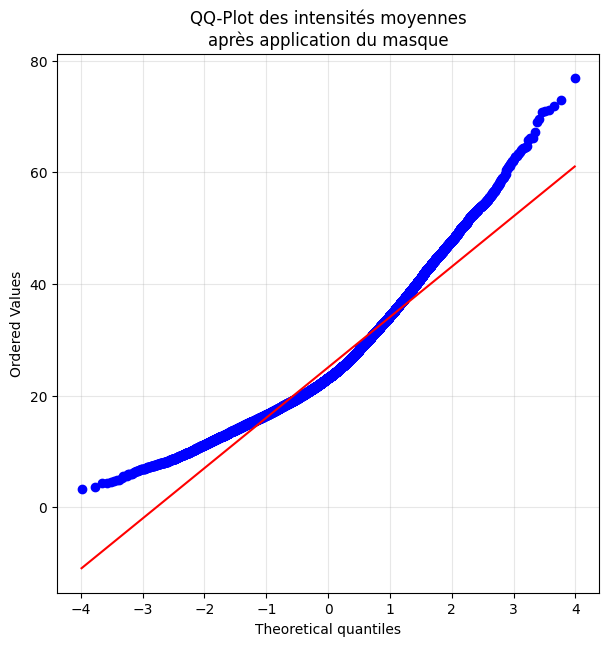

In [59]:
plt.figure(figsize=(7, 7))

stats.probplot(
    df_masked_images["pixel_mean"],
    dist="norm",
    plot=plt
)

plt.title(
    "QQ-Plot des intensités moyennes\n"
    "après application du masque"
)
plt.grid(alpha=0.3)

plt.show()

Le QQ-Plot met en évidence des écarts importants par rapport à la droite de référence, notamment aux extrémités de la distribution. Ces écarts confirment que les intensités moyennes après application du masque ne suivent pas une loi normale, en cohérence avec le test de D'Agostino-Pearson.

##### Boxplot

C:\Users\n_a_e\AppData\Local\Temp\ipykernel_22368\3646666377.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


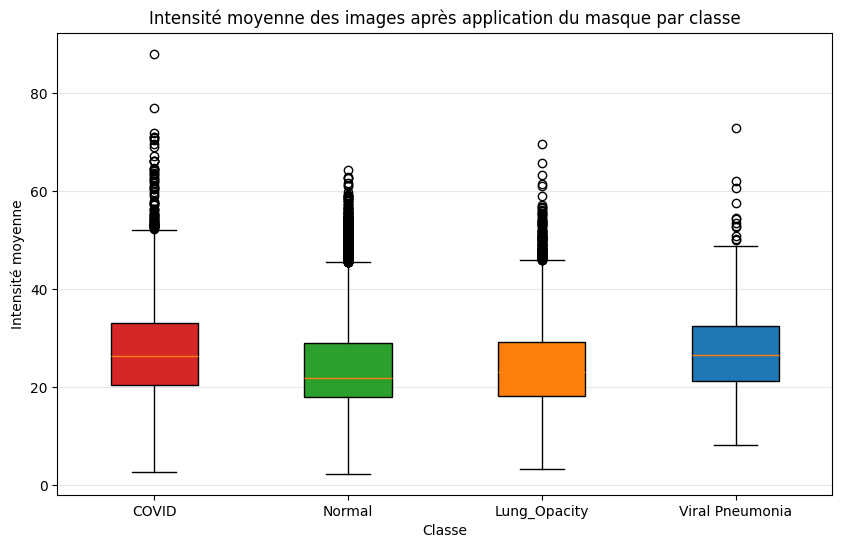

In [40]:
colors = {
    "COVID": "#d62728",           
    "Normal": "#2ca02c",        
    "Lung_Opacity": "#ff7f0e",    
    "Viral Pneumonia": "#1f77b4" 
}

data_to_plot = [
    df_masked_images[df_masked_images["classe"] == class_name]["pixel_mean"]
    for class_name in classes
]

fig, ax = plt.subplots(figsize=(10, 6))

box = ax.boxplot(
    data_to_plot,
    patch_artist=True,
    labels=classes
)

# Application des couleurs
for patch, class_name in zip(box['boxes'], classes):
    patch.set_facecolor(colors[class_name])

plt.title("Intensité moyenne des images après application du masque par classe")
plt.xlabel("Classe")
plt.ylabel("Intensité moyenne")
plt.grid(axis="y", alpha=0.3)

plt.show()

Après application du masque, les intensités moyennes diffèrent selon les classes. Les images COVID et Viral Pneumonia présentent une médiane légèrement plus élevée que les classes Normal et Lung_Opacity, mais les distributions restent largement chevauchantes. La présence de nombreux points atypiques dans toutes les classes traduit une forte variabilité intra-classe.

In [60]:
# Test de kruskal wallis

groupes = [
    df_masked_images.loc[df_masked_images["classe"] == c, "pixel_mean"]
    for c in classes
]

stat, p = kruskal(*groupes)

print(f"Statistique du test : {stat:.4f}")
print(f"p-value : {p:.4e}")

if p < 0.05:
    print("Conclusion : au moins une classe diffère significativement.")
else:
    print("Conclusion : aucune différence significative entre les classes.")

Statistique du test : 445.8583
p-value : 2.5739e-96
Conclusion : au moins une classe diffère significativement.


Le test de Kruskal-Wallis met en évidence une différence statistiquement significative de l'intensité moyenne des images masquées entre au moins deux classes. Le test post-hoc de Dunn permet ensuite d'identifier précisément quelles paires de classes présentent des différences significatives.

In [61]:
dunn = sp.posthoc_dunn(
    df_masked_images,
    val_col="pixel_mean",
    group_col="classe",
    p_adjust="bonferroni"
)

display(dunn)

,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,1.000000e+00,5.350999e-42,6.222707e-68,5.077525e-01
Lung_Opacity,5.350999e-42,1.000000e+00,6.754643e-03,2.390873e-30
Normal,6.222707e-68,6.754643e-03,1.000000e+00,4.524014e-43
Viral Pneumonia,5.077525e-01,2.390873e-30,4.524014e-43,1.000000e+00


Le test post-hoc de Dunn montre que la plupart des paires de classes présentent des différences significatives d'intensité moyenne après application du masque (p < 0,05). En revanche, aucune différence significative n'est observée entre les classes COVID et Viral Pneumonia (p = 0,508), suggérant une forte similarité de leurs intensités moyennes après segmentation pulmonaire.

#### Ecart type de l'intensité des pixels

##### Distribution et normalité

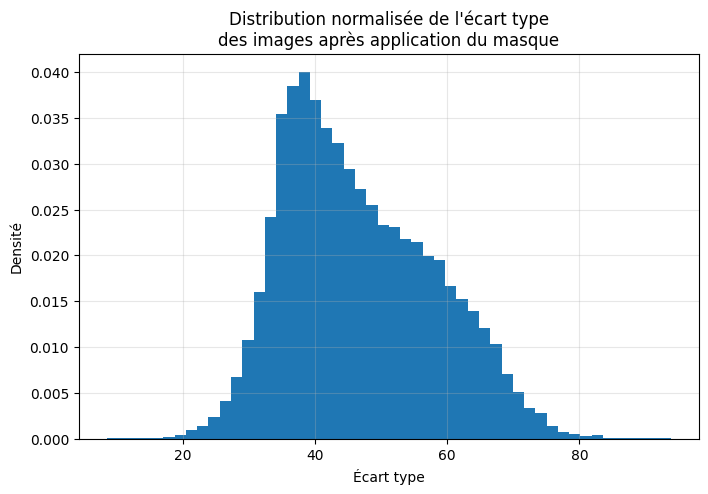

In [62]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_masked_images["pixel_std"],
    bins=50,
    density=True
)

plt.title(
    "Distribution normalisée de l'écart type\n"
    "des images après application du masque"
)

plt.xlabel("Écart type")
plt.ylabel("Densité")

plt.grid(alpha=0.3)

plt.show()

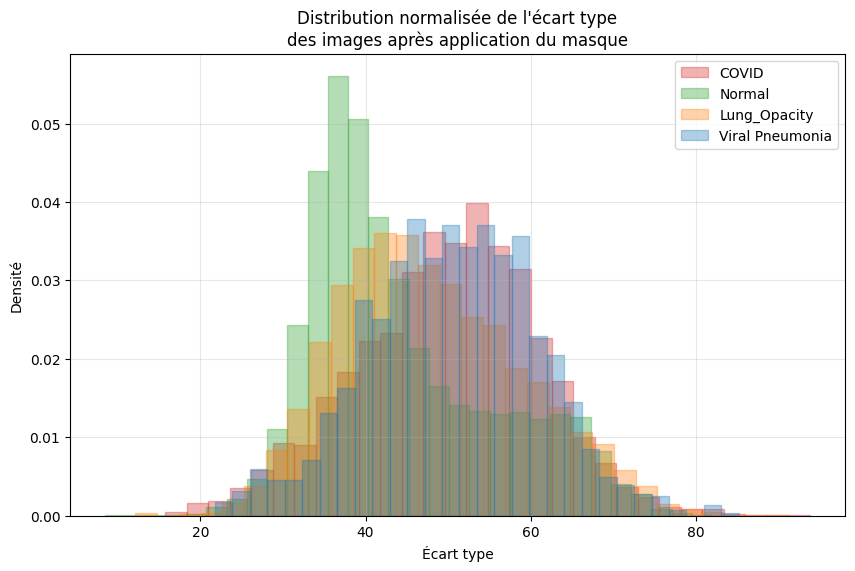

In [63]:
colors = {
    "COVID": "#d62728",
    "Normal": "#2ca02c",
    "Lung_Opacity": "#ff7f0e",
    "Viral Pneumonia": "#1f77b4"
}

plt.figure(figsize=(10, 6))

for class_name in classes:

    subset = df_masked_images[
        df_masked_images["classe"] == class_name
    ]

    plt.hist(
        subset["pixel_std"],
        bins=30,
        density=True,
        alpha=0.35,
        color=colors[class_name],
        edgecolor=colors[class_name],
        label=class_name
    )

plt.title(
    "Distribution normalisée de l'écart type\n"
    "des images après application du masque"
)

plt.xlabel("Écart type")
plt.ylabel("Densité")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Après application du masque, les distributions des écarts types diffèrent selon les classes. La classe Normal présente des écarts types globalement plus faibles, tandis que les classes COVID et Viral Pneumonia sont décalées vers des valeurs plus élevées. Malgré ces différences, un recouvrement important subsiste entre les distributions, suggérant que l'écart type seul ne permet pas de distinguer parfaitement les classes.

In [64]:
# Test de normalité sur l'écart type après application du masque

valeurs = df_masked_images["pixel_std"].dropna()

stat, p_value = normaltest(valeurs)

print(f"Statistique du test : {stat:.4f}")
print(f"p-value : {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion : la distribution ne suit pas une loi normale (H0 rejetée).")
else:
    print("Conclusion : aucune preuve de non-normalité (H0 non rejetée).")

Statistique du test : 869.0587
p-value : 1.9333e-189
Conclusion : la distribution ne suit pas une loi normale (H0 rejetée).


La distribution des écarts types après application du masque ne suit pas une loi normale (D'Agostino-Pearson, p < 0,001). Des tests non paramétriques seront donc privilégiés pour les comparaisons entre classes.

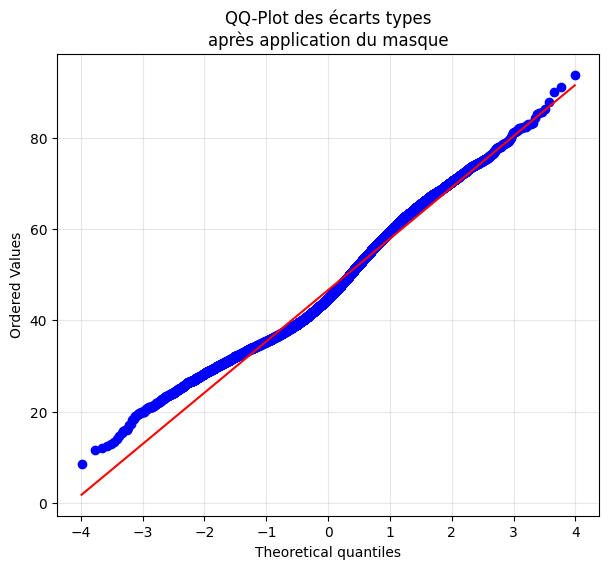

In [65]:
# QQplot

plt.figure(figsize=(7, 6))

stats.probplot(
    df_masked_images["pixel_std"],
    dist="norm",
    plot=plt
)

plt.title(
    "QQ-Plot des écarts types\n"
    "après application du masque"
)

plt.xlabel("Theoretical quantiles")
plt.ylabel("Ordered Values")

plt.grid(alpha=0.3)

plt.show()

Le QQ-Plot montre un bon alignement au centre de la distribution, mais des écarts dans les extrémités, confirmant la non-normalité des écarts types après application du masque.

##### Boxplots

C:\Users\n_a_e\AppData\Local\Temp\ipykernel_37188\1969894473.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


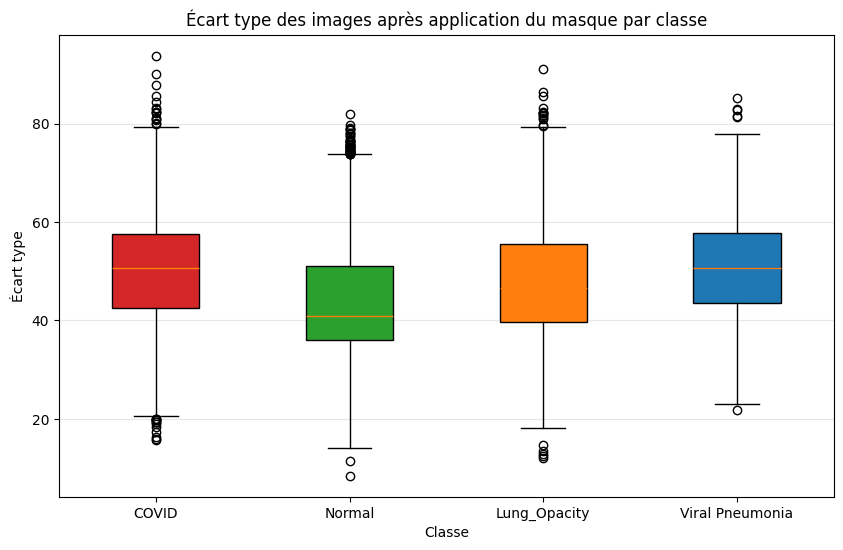

In [66]:
colors = {
    "COVID": "#d62728",
    "Normal": "#2ca02c",
    "Lung_Opacity": "#ff7f0e",
    "Viral Pneumonia": "#1f77b4"
}

data_to_plot = [
    df_masked_images[df_masked_images["classe"] == class_name]["pixel_std"]
    for class_name in classes
]

fig, ax = plt.subplots(figsize=(10, 6))

box = ax.boxplot(
    data_to_plot,
    patch_artist=True,
    labels=classes
)

# Application des couleurs
for patch, class_name in zip(box["boxes"], classes):
    patch.set_facecolor(colors[class_name])

plt.title("Écart type des images après application du masque par classe")
plt.xlabel("Classe")
plt.ylabel("Écart type")
plt.grid(axis="y", alpha=0.3)

plt.show()

Le boxplot montre que les écarts types des images après application du masque diffèrent selon les classes. Les classes COVID et Viral Pneumonia présentent des médianes plus élevées, indiquant une plus grande variabilité des intensités de pixels après masquage. À l'inverse, la classe Normal possède la médiane la plus faible. Malgré un important chevauchement entre les distributions, ces différences suggèrent une variabilité du contraste propre à chaque classe, qui pourra être confirmée statistiquement.

In [67]:
# test kruskal wallis

stat, p = kruskal(
    df_masked_images[df_masked_images["classe"] == "COVID"]["pixel_std"],
    df_masked_images[df_masked_images["classe"] == "Normal"]["pixel_std"],
    df_masked_images[df_masked_images["classe"] == "Lung_Opacity"]["pixel_std"],
    df_masked_images[df_masked_images["classe"] == "Viral Pneumonia"]["pixel_std"]
)

print(f"Statistique du test : {stat:.4f}")
print(f"p-value : {p:.4e}")

if p < 0.05:
    print("Conclusion : au moins une classe diffère significativement.")
else:
    print("Conclusion : aucune différence significative entre les classes.")

Statistique du test : 1269.5913
p-value : 5.8325e-275
Conclusion : au moins une classe diffère significativement.


In [68]:
dunn = sp.posthoc_dunn(
    df_masked_images,
    val_col="pixel_std",
    group_col="classe",
    p_adjust="bonferroni"
)

display(dunn)

,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,1.000000e+00,7.138514e-21,3.387353e-184,6.744106e-01
Lung_Opacity,7.138514e-21,1.000000e+00,8.961465e-114,1.121848e-16
Normal,3.387353e-184,8.961465e-114,1.000000e+00,1.474955e-102
Viral Pneumonia,6.744106e-01,1.121848e-16,1.474955e-102,1.000000e+00


Les écarts types après application du masque diffèrent significativement entre les classes (Kruskal-Wallis, p < 0,001). Le test de Dunn indique que seule la comparaison entre COVID et Viral Pneumonia n'est pas significative, suggérant une variabilité des intensités similaire entre ces deux classes après masquage.

## 9. ACP

In [57]:
# Préparation des images

Data_path = Path("../../../COVID-19_Radiography_Dataset")

classes = ["Normal", "Lung_Opacity", "Viral Pneumonia", "COVID"]

colors = {
    "COVID": "#d62728",
    "Normal": "#2ca02c",
    "Lung_Opacity": "#ff7f0e",
    "Viral Pneumonia": "#1f77b4"
}

target_size = (128, 128)  # taille réduite pour ACP

In [42]:
# Préparation des matrices

def load_images_for_pca(data_path, classes, mode="raw", target_size=(64, 64)):
    """
    mode :
    - "raw"    : images brutes
    - "mask"   : masques seuls
    - "masked" : images après application du masque
    """
    
    X = []
    y = []
    filenames = []
    
    for class_name in classes:
        images_dir = data_path / class_name / "images"
        masks_dir = data_path / class_name / "masks"
        
        image_files = sorted(images_dir.glob("*.png"))
        
        for img_path in image_files:
            mask_path = masks_dir / img_path.name
            
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            
            if img is None or mask is None:
                continue
            
            if mode == "raw":
                img_to_use = img
            
            elif mode == "mask":
                img_to_use = mask
            
            elif mode == "masked":
                h, w = img.shape
                
                mask_resized = cv2.resize(
                    mask,
                    (w, h),
                    interpolation=cv2.INTER_NEAREST
                )
                
                mask_binary = np.where(mask_resized > 0, 255, 0).astype(np.uint8)
                img_to_use = cv2.bitwise_and(img, img, mask=mask_binary)
            
            else:
                raise ValueError("mode doit être 'raw', 'mask' ou 'masked'")
            
            img_resized = cv2.resize(
                img_to_use,
                target_size,
                interpolation=cv2.INTER_AREA
            )
            
            X.append(img_resized.ravel())
            y.append(class_name)
            filenames.append(img_path.name)
    
    X = np.array(X)
    y = np.array(y)
    
    return X, y, filenames

In [45]:
# Fonction ACP et graphiques

def run_pca_and_plot(X, y, title):
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    df_pca = pd.DataFrame({
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "classe": y
    })
    
    plt.figure(figsize=(9, 7))
    
    for class_name in classes:
        subset = df_pca[df_pca["classe"] == class_name]
        
        plt.scatter(
            subset["PC1"],
            subset["PC2"],
            label=class_name,
            color=colors[class_name],
            alpha=0.3,   # transparence ici
            s=20
        )
    
    plt.title(title)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f} %)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f} %)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    print("Variance expliquée PC1 :", round(pca.explained_variance_ratio_[0] * 100, 2), "%")
    print("Variance expliquée PC2 :", round(pca.explained_variance_ratio_[1] * 100, 2), "%")
    print("Variance expliquée totale :", round(pca.explained_variance_ratio_[:2].sum() * 100, 2), "%")
    
    return df_pca, pca

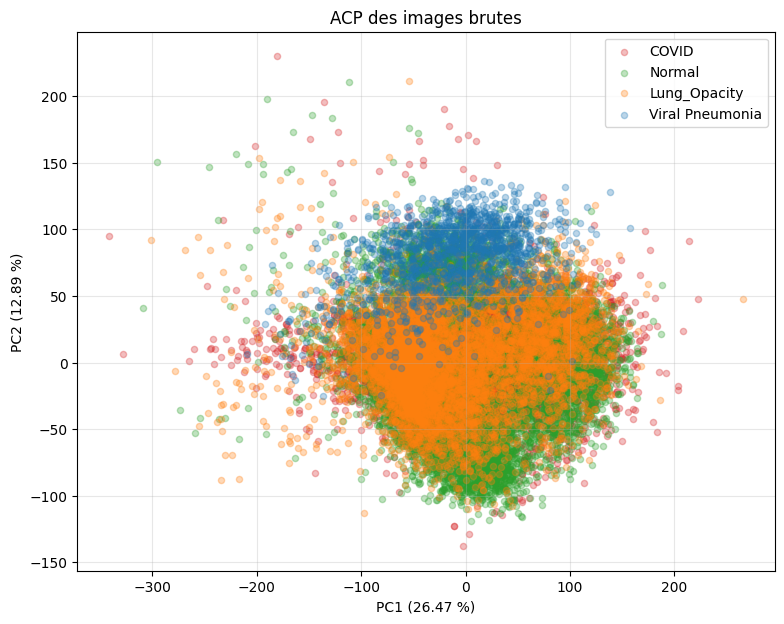

Variance expliquée PC1 : 26.47 %
Variance expliquée PC2 : 12.89 %
Variance expliquée totale : 39.36 %


In [54]:
# ACP images brutes

X_raw, y_raw, files_raw = load_images_for_pca(
    data_path,
    classes,
    mode="raw",
    target_size=target_size
)

df_pca_raw, pca_raw = run_pca_and_plot(
    X_raw,
    y_raw,
    "ACP des images brutes"
)

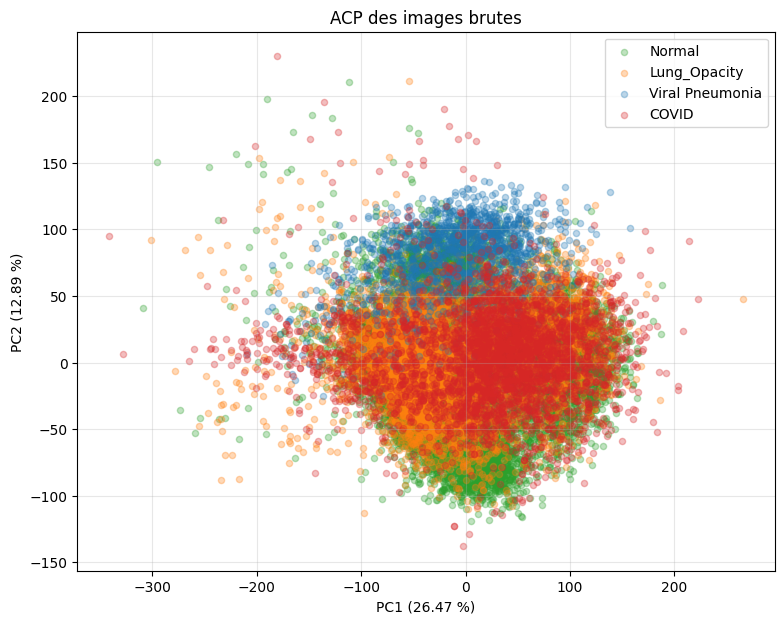

Variance expliquée PC1 : 26.47 %
Variance expliquée PC2 : 12.89 %
Variance expliquée totale : 39.36 %


In [59]:
# ACP images brutes avec les COVID en avant

X_raw, y_raw, files_raw = load_images_for_pca(
    data_path,
    classes,
    mode="raw",
    target_size=target_size
)

df_pca_raw, pca_raw = run_pca_and_plot(
    X_raw,
    y_raw,
    "ACP des images brutes"
)

Les deux premières composantes expliquent 39,36 % de la variance. L'ACP révèle un fort chevauchement entre les quatre classes, indiquant qu'une projection linéaire en deux dimensions ne permet pas de les discriminer clairement, malgré une légère tendance de la classe Viral Pneumonia à se distinguer selon la deuxième composante.

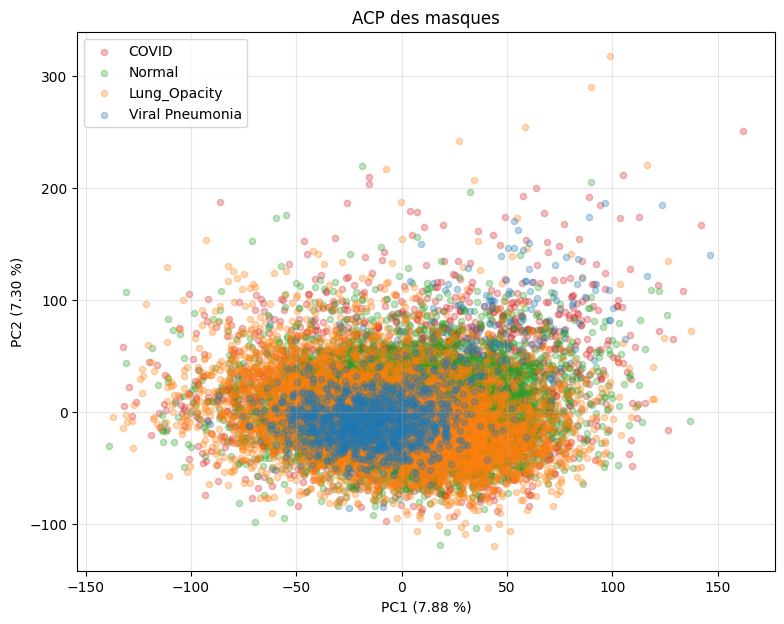

Variance expliquée PC1 : 7.88 %
Variance expliquée PC2 : 7.3 %
Variance expliquée totale : 15.17 %


In [55]:
# ACP Masks

X_masks, y_masks, files_masks = load_images_for_pca(
    data_path,
    classes,
    mode="mask",
    target_size=target_size
)

df_pca_masks, pca_masks = run_pca_and_plot(
    X_masks,
    y_masks,
    "ACP des masques"
)

L'ACP appliquée aux masques révèle un important recouvrement entre les quatre classes et une faible variance expliquée (15,17 %). Contrairement aux images brutes, les deux premières composantes capturent peu d'information, suggérant que la géométrie globale des masques ne permet pas de distinguer efficacement les différentes pathologies.

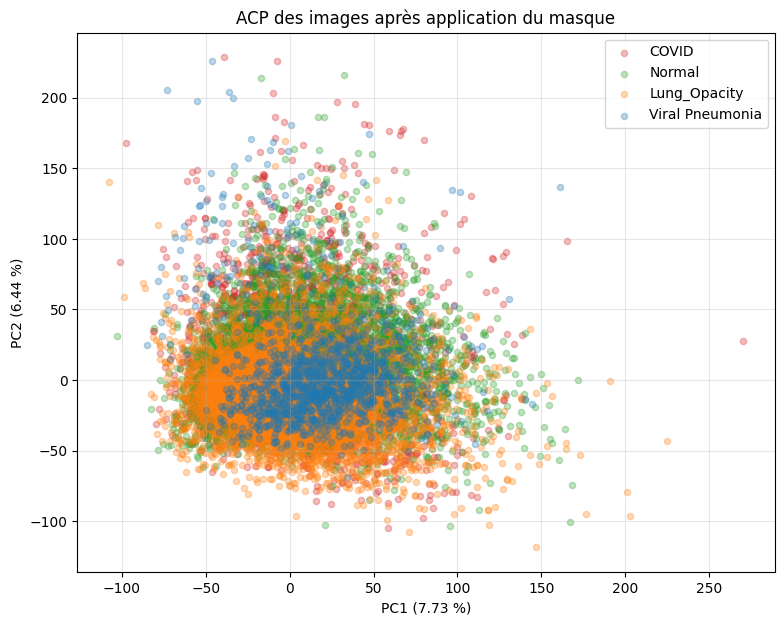

Variance expliquée PC1 : 7.73 %
Variance expliquée PC2 : 6.44 %
Variance expliquée totale : 14.17 %


In [56]:
# ACP images masquées

X_masked, y_masked, files_masked = load_images_for_pca(
    data_path,
    classes,
    mode="masked",
    target_size=target_size
)

df_pca_masked, pca_masked = run_pca_and_plot(
    X_masked,
    y_masked,
    "ACP des images après application du masque"
)

L'ACP des images masquées confirme un fort recouvrement entre les quatre classes et une faible variance expliquée (14,17 %). L'application du masque ne suffit donc pas, à elle seule, à améliorer la séparabilité des classes dans l'espace des deux premières composantes principales.

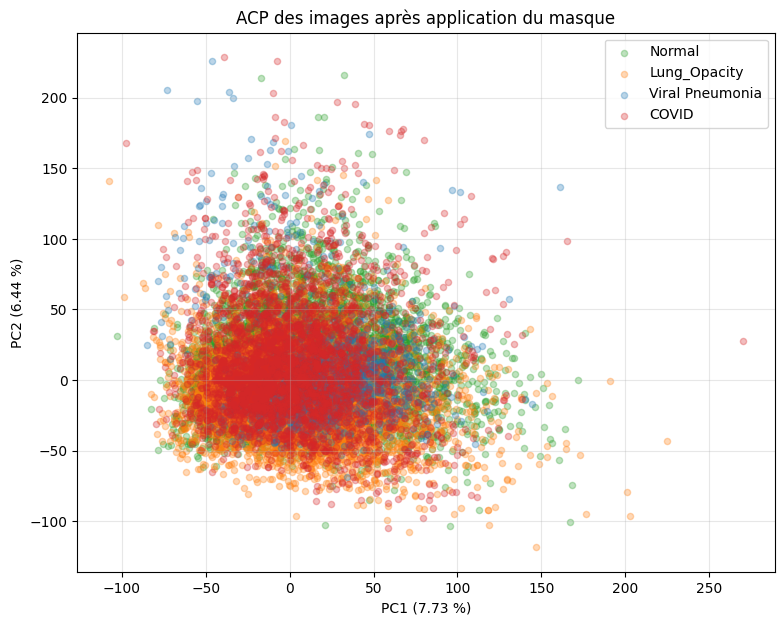

Variance expliquée PC1 : 7.73 %
Variance expliquée PC2 : 6.44 %
Variance expliquée totale : 14.17 %


In [58]:
# ACP images masquées avec les COVID en avant

X_masked, y_masked, files_masked = load_images_for_pca(
    data_path,
    classes,
    mode="masked",
    target_size=target_size
)

df_pca_masked, pca_masked = run_pca_and_plot(
    X_masked,
    y_masked,
    "ACP des images après application du masque"
)